In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Initial Analysis**

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD THE DATASET
# ==========================================
print("Loading NHIS 2022 dataset... (This might take a moment due to file size)")
file_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/adult22.csv'
df = pd.read_csv(file_path)

# ==========================================
# 2. HIGH-LEVEL OVERVIEW
# ==========================================
print("\n" + "="*40)
print("=== NHIS 2022 DATASET OVERVIEW ===")
print("="*40)
print(f"Total Participants (Rows): {df.shape[0]:,}")
print(f"Total Features (Columns):  {df.shape[1]:,}")

# ==========================================
# 3. MISSING VALUE ANALYSIS
# ==========================================
print("\n" + "="*40)
print("=== MISSING VALUE ANALYSIS ===")
print("="*40)
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

# Create a clean dataframe for missing stats
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage (%)': missing_percent
})

# Filter only columns that actually have missing data, sort descending
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

if missing_df.empty:
    print("Incredible! There are absolutely no missing values in this raw dataset.")
else:
    print(f"Out of {df.shape[1]} columns, {len(missing_df)} have missing data.")
    print("\nTop 15 columns with the most missing data:")
    print(missing_df.head(15).round(2))

# ==========================================
# 4. TARGET VARIABLE DETECTION (ARTHRITIS)
# ==========================================
print("\n" + "="*40)
print("=== TARGET VARIABLE SEARCH ===")
print("="*40)
# Search for standard NHIS arthritis column names or anything containing 'arth'
potential_targets = [col for col in df.columns if 'arth' in col.lower() or col.upper() in ['ARTH1_A', 'ARTCUREC_A']]

if potential_targets:
    print(f"Found {len(potential_targets)} potential Arthritis-related column(s): {potential_targets}")
    for col in potential_targets:
        print(f"\n--- Distribution for '{col}' ---")
        print(df[col].value_counts(dropna=False).sort_index())
else:
    print("Could not automatically identify columns containing 'arth'.")
    print("We will need to manually check the NHIS 2022 codebook to find the target variable's exact name.")

Loading NHIS 2022 dataset... (This might take a moment due to file size)

=== NHIS 2022 DATASET OVERVIEW ===
Total Participants (Rows): 27,651
Total Features (Columns):  637

=== MISSING VALUE ANALYSIS ===
Out of 637 columns, 397 have missing data.

Top 15 columns with the most missing data:
              Missing Count  Percentage (%)
OGFLG_A               27651          100.00
CHFLG_A               27651          100.00
PRPLCOV2_C_A          27651          100.00
CHHDHP_A              27650          100.00
LARYNAGETC_A          27647           99.99
OPFLG_A               27647           99.99
GALLBAGETC_A          27645           99.98
CHXCHNG_A             27641           99.96
CHPREM_A              27641           99.96
CHDEDUC_A             27641           99.96
ESOPHAGETC_A          27638           99.95
OGHDHP_A              27637           99.95
BRAINAGETC_A          27633           99.93
BONEAGETC_A           27633           99.93
PANCRAGETC_A          27631           99.93

==

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/adult22.csv'

# We use nrows=0 to load ONLY the column names, saving massive amounts of memory and time
print("Fetching column names from NHIS 2022...")
df_headers = pd.read_csv(file_path, nrows=0)

all_columns = df_headers.columns.tolist()

print(f"\nTotal columns found: {len(all_columns)}")
print("="*50)
print("ALL FEATURE NAMES IN DATASET:")
print("="*50)

# Print columns in neat rows of 5 so it doesn't flood your screen with a giant single column
for i in range(0, len(all_columns), 5):
    print(", ".join(all_columns[i:i+5]))

print("\n" + "="*50)
print("SEARCHING FOR LIKELY MATCHES FOR 'EDUCATION':")
# Let's also do a quick automatic search to find the education column
edu_cols = [col for col in all_columns if 'EDU' in col.upper()]
print(edu_cols)

Fetching column names from NHIS 2022...

Total columns found: 637
ALL FEATURE NAMES IN DATASET:
URBRRL, RATCAT_A, INCTCFLG_A, IMPINCFLG_A, SHOTTYPE1_A
CEVOTELC_A, CEMMETNG_A, CEVOLUN2_A, CEVOLUN1_A, HITTEST_A
HITCOMM_A, HITLOOK_A, ACCSSHOM_A, ACCSSINT_A, PPSU
PSTRAT, WLKLEISTC_A, WLKTRANTC_A, HISPALLP_A, RACEALLP_A
DISAB3_A, SCHDYMSSTC_A, AFNOW, PHQCAT_A, YRSINUS_A
CITZNSTP_A, PRTNREDUCP_A, SPOUSEDUCP_A, LEGMSTAT_A, MARSTAT_A
SASPPRACE_A, SASPPHISP_A, PRTNRAGETC_A, SPOUSAGETC_A, PRTNRWKFT_A
PRTNRWRK_A, SPOUSWKFT_A, SPOUSWRK_A, SPOUSESEX_A, PRTNRSEX_A
SHOTTYPER_A, SHINGYEARP_A, HHRESPSA_FLG, GADCAT_A, PCNTADTWFP_A
PCNTADTWKP_A, FDSCAT4_A, FDSCAT3_A, EPINUMSEZP_A, EMPDYSMSS3_A
EMPLSTWOR1_A, EMPWRKFT1_A, EMPWRKLSW1_A, EMPWKHRS3_A, DIBAGETC_A
DIFYRSTC1_A, SMKQTNP_A, SMKQTY_A, SMKECIGST_A, SMKCIGST_A
BMICAT_A, WEIGHTLBTC_A, HEIGHTTC_A, DRKHVY12M_A, DRKSTAT_A
DRK12MYR_A, DRK12MWK_A, URGNT12MTC_A, EMERG12MTC_A, PA18_05R_A
PA18_02R_A, MODFREQW_A, MODNR_A, MODTPR_A, MODLNR_A
MODLTPR_A, MODMIN_A

# **Rename Features**

In [ ]:
import pandas as pd

# ==========================================
# 1. DEFINE THE FEATURE MAPPING
# ==========================================
# Dictionary mapping the verified NHIS 2022 Variable Names to your New Feature Names
nhis_feature_mapping = {
    'AGEP_A': 'Age',
    'HISPALLP_A': 'Race',
    'SEX_A': 'Gender',
    'RATCAT_A': 'Income level',
    'EDUCP_A': 'Education level',              # Corrected based on your extraction
    'MARITAL_A': 'Marital status',
    'SMKEV_A': 'Smoking status',
    'DRKBNG30D_A': 'Alcohol consumption',
    'MODTPR_A': 'Physical activity',
    'WELLVIS_A': 'Regular checkup',
    'HOUTENURE_A': 'Housing status',
    'HEARINGDF_A': 'DEAF',
    'BMICAT_A': 'BMI',
    'VISIONDF_A': 'BLIND',
    'COGMEMDFF_A': 'Difficulty concentrating',
    'DIFF_A': 'Difficulty walking',
    'HICOV_A': 'Health insurance',
    'MHTHRPY_A': 'Mental health',
    'HYPMED_A': 'Blood pressure',
    'CHLEV_A': 'Cholesterol awareness',
    'ARTHEV_A': 'Arthritis'
}

# ==========================================
# 2. LOAD, FILTER, AND RENAME
# ==========================================
print("Loading NHIS 2022 raw dataset...")
file_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/adult22.csv'

# Load only the columns we need to save RAM
original_columns = list(nhis_feature_mapping.keys())
df_nhis = pd.read_csv(file_path, usecols=original_columns)

print(f"Original shape before renaming: {df_nhis.shape}")

# Rename the columns using our dictionary
df_nhis = df_nhis.rename(columns=nhis_feature_mapping)

# ==========================================
# 3. VERIFY AND SAVE
# ==========================================
print(f"\nSuccessfully extracted and renamed {df_nhis.shape[1]} features.")
print("\n--- Current Features in Dataset ---")
print(df_nhis.columns.tolist())

# Save this newly extracted dataset to drive
save_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Extracted_21_Features.csv'
df_nhis.to_csv(save_path, index=False)
print(f"\nExtracted dataset saved to: {save_path}")

# Display a quick preview of the top 5 rows
display(df_nhis.head())

Loading NHIS 2022 raw dataset...
Original shape before renaming: (27651, 21)

Successfully extracted and renamed 21 features.

--- Current Features in Dataset ---
['Income level', 'Race', 'BMI', 'Physical activity', 'Education level', 'Gender', 'Age', 'Housing status', 'Marital status', 'Alcohol consumption', 'Smoking status', 'Mental health', 'Regular checkup', 'Health insurance', 'Difficulty concentrating', 'Difficulty walking', 'DEAF', 'BLIND', 'Arthritis', 'Cholesterol awareness', 'Blood pressure']

Extracted dataset saved to: /content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Extracted_21_Features.csv


,Income level,Race,BMI,Physical activity,Education level,Gender,Age,Housing status,Marital status,Alcohol consumption,...,Mental health,Regular checkup,Health insurance,Difficulty concentrating,Difficulty walking,DEAF,BLIND,Arthritis,Cholesterol awareness,Blood pressure
0,7,2,2,2,4,1,85,1,3,NaN,...,2,NaN,1,1,2,2,1,2,2,1.0
1,14,2,4,2,8,1,64,1,1,99.0,...,2,NaN,1,1,1,1,1,2,1,1.0
2,14,2,4,2,8,2,37,1,1,NaN,...,2,NaN,1,1,2,1,1,2,2,NaN
3,11,2,4,0,5,2,72,1,2,NaN,...,2,NaN,1,1,2,1,1,2,2,2.0
4,2,3,3,0,6,2,84,1,3,NaN,...,2,NaN,1,1,2,1,1,1,2,1.0


# **Analysis**

In [ ]:
import pandas as pd

# Load the filtered NHIS dataset we saved earlier
file_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Extracted_21_Features.csv'
df_nhis_2022 = pd.read_csv(file_path)

print("=== DETAILED VALUE COUNTS FOR EVERY FEATURE ===")
print("Showing ALL unique values sorted in numerical order:\n")

for col in df_nhis_2022.columns:
    print(f"--- {col} ---")
    # sort_index() keeps the categories in order (e.g., 1, 2, 3... 7, 8, 9, NaN)
    print(df_nhis_2022[col].value_counts(dropna=False).sort_index())
    print("-" * 30 + "\n")

=== DETAILED VALUE COUNTS FOR EVERY FEATURE ===
Showing ALL unique values sorted in numerical order:

--- Income level ---
Income level
1      794
2      820
3     1166
4     1174
5     1316
6     1006
7     1343
8     2410
9     1903
10    1825
11    1855
12    1496
13    1575
14    8968
Name: count, dtype: int64
------------------------------

--- Race ---
Race
1     3943
2    18242
3     3112
4     1663
5      187
6      185
7      319
Name: count, dtype: int64
------------------------------

--- BMI ---
BMI
1     432
2    8494
3    9285
4    8814
9     626
Name: count, dtype: int64
------------------------------

--- Physical activity ---
Physical activity
0     7669
1     4050
2    13399
3     1227
4      167
5      113
6      164
7       22
8      774
9       66
Name: count, dtype: int64
------------------------------

--- Education level ---
Education level
1     1881
2      488
3      632
4     6351
5     4112
6     1065
7     2561
8     6307
9     3025
10    1080
97      48
99

# **Mapping**

In [ ]:
import pandas as pd
import numpy as np

# ==========================================
# 1. LOAD THE EXTRACTED DATASET
# ==========================================
print("Loading extracted NHIS 2022 dataset...")
file_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Extracted_21_Features.csv'
df = pd.read_csv(file_path)

# ==========================================
# 2. DEFINE MAPPING LOGIC
# ==========================================
print("Applying NHIS codebook mappings...")

# 1. Age (Binning raw ages 18-85+ into 14 categories)
df['Age'] = df['Age'].replace([97, 98, 99], np.nan)
age_bins = [17, 24, 29, 34, 39, 44, 49, 54, 59, 64, 69, 74, 79, 84, 150]
age_labels = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
df['Age'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels).astype('float')

# 2. Gender (1: Male -> 1, 2: Female -> 0)
df['Gender'] = df['Gender'].replace({2: 0, 7: np.nan, 8: np.nan, 9: np.nan})

# 3. Race & Income Level (Keep as is, just clear unknowns)
df['Race'] = df['Race'].replace([8, 9, 97, 99], np.nan)
df['Income level'] = df['Income level'].apply(lambda x: x if x <= 14 else np.nan)

# 4. Education level & BMI
df['Education level'] = df['Education level'].replace([97, 98, 99], np.nan)
df['BMI'] = df['BMI'].replace([9], np.nan)

# 5. Marital status (1: Married -> 1, 2: Living with partner -> 2, 3: Neither -> 0)
df['Marital status'] = df['Marital status'].replace({3: 0, 7: np.nan, 8: np.nan, 9: np.nan})

# 6. Alcohol consumption (0 -> 0, 1 to 60 -> 1)
df['Alcohol consumption'] = df['Alcohol consumption'].apply(
    lambda x: 0 if x == 0 else (1 if 1 <= x <= 60 else np.nan)
)

# 7. Physical activity, Regular checkup, Housing status (Keep valid ranges, drop unknowns)
df['Physical activity'] = df['Physical activity'].replace([7, 8, 9], np.nan)
df['Regular checkup'] = df['Regular checkup'].replace([7, 8, 9], np.nan)
df['Housing status'] = df['Housing status'].replace([7, 8, 9], np.nan)

# 8. Disability Features (1->0, 2->1, 3->2, 4->3)
disability_cols = ['DEAF', 'BLIND', 'Difficulty concentrating', 'Difficulty walking']
for col in disability_cols:
    df[col] = df[col].replace({1: 0, 2: 1, 3: 2, 4: 3, 7: np.nan, 8: np.nan, 9: np.nan})

# 9. Binary Features (1: Yes -> 1, 2: No -> 0)
binary_cols = ['Smoking status', 'Health insurance', 'Mental health',
               'Blood pressure', 'Cholesterol awareness', 'Arthritis']
for col in binary_cols:
    df[col] = df[col].replace({2: 0, 7: np.nan, 8: np.nan, 9: np.nan})

# ==========================================
# 3. VERIFY AND SAVE
# ==========================================
print("\n=== MAPPED VALUE COUNTS (PREVIEW) ===")
features_to_check = ['Age', 'Gender', 'Marital status', 'Alcohol consumption', 'Arthritis', 'DEAF']
for col in features_to_check:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())

# Save the mapped dataset
save_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Mapped.csv'
df.to_csv(save_path, index=False)
print(f"\nPerfectly mapped dataset saved to: {save_path}")

Loading extracted NHIS 2022 dataset...
Applying NHIS codebook mappings...

=== MAPPED VALUE COUNTS (PREVIEW) ===

--- Age ---
Age
1.0     1732
2.0     1821
3.0     2194
4.0     2198
5.0     2085
6.0     1881
7.0     1970
8.0     2276
9.0     2659
10.0    2671
11.0    2343
12.0    1654
13.0    1101
14.0    1002
NaN       64
Name: count, dtype: int64

--- Gender ---
Gender
0.0    15050
1.0    12598
NaN        3
Name: count, dtype: int64

--- Marital status ---
Marital status
0.0    12432
1.0    12278
2.0     1763
NaN     1178
Name: count, dtype: int64

--- Alcohol consumption ---
Alcohol consumption
0.0     1621
1.0     3822
NaN    22208
Name: count, dtype: int64

--- Arthritis ---
Arthritis
0.0    20303
1.0     7296
NaN       52
Name: count, dtype: int64

--- DEAF ---
DEAF
0.0    22768
1.0     4389
2.0      458
3.0       25
NaN       11
Name: count, dtype: int64

Perfectly mapped dataset saved to: /content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Mapped.csv


In [ ]:
df

,Income level,Race,BMI,Physical activity,Education level,Gender,Age,Housing status,Marital status,Alcohol consumption,...,Mental health,Regular checkup,Health insurance,Difficulty concentrating,Difficulty walking,DEAF,BLIND,Arthritis,Cholesterol awareness,Blood pressure
0,7,2,2.0,2.0,4.0,1.0,14.0,1.0,0.0,NaN,...,0.0,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,14,2,4.0,2.0,8.0,1.0,9.0,1.0,1.0,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,14,2,4.0,2.0,8.0,0.0,4.0,1.0,1.0,NaN,...,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN
3,11,2,4.0,0.0,5.0,0.0,11.0,1.0,2.0,NaN,...,0.0,NaN,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,2,3,3.0,0.0,6.0,0.0,13.0,1.0,0.0,NaN,...,0.0,NaN,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27646,11,2,3.0,1.0,4.0,1.0,9.0,1.0,0.0,NaN,...,0.0,6.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,NaN
27647,10,2,2.0,2.0,8.0,0.0,10.0,1.0,1.0,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0,1.0,NaN
27648,13,2,2.0,0.0,7.0,0.0,10.0,1.0,1.0,NaN,...,0.0,NaN,1.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN
27649,8,2,4.0,2.0,7.0,1.0,3.0,1.0,1.0,NaN,...,0.0,NaN,1.0,0.0,0.0,1.0,0.0,0.0,1.0,NaN


Loading mapped NHIS 2022 dataset...
Dataset loaded successfully. Shape: (27651, 21)
Calculating correlation matrix...
Generating heatmap with values...
Correlation heatmap saved successfully to: /content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Correlation_Heatmap_With_Values.png


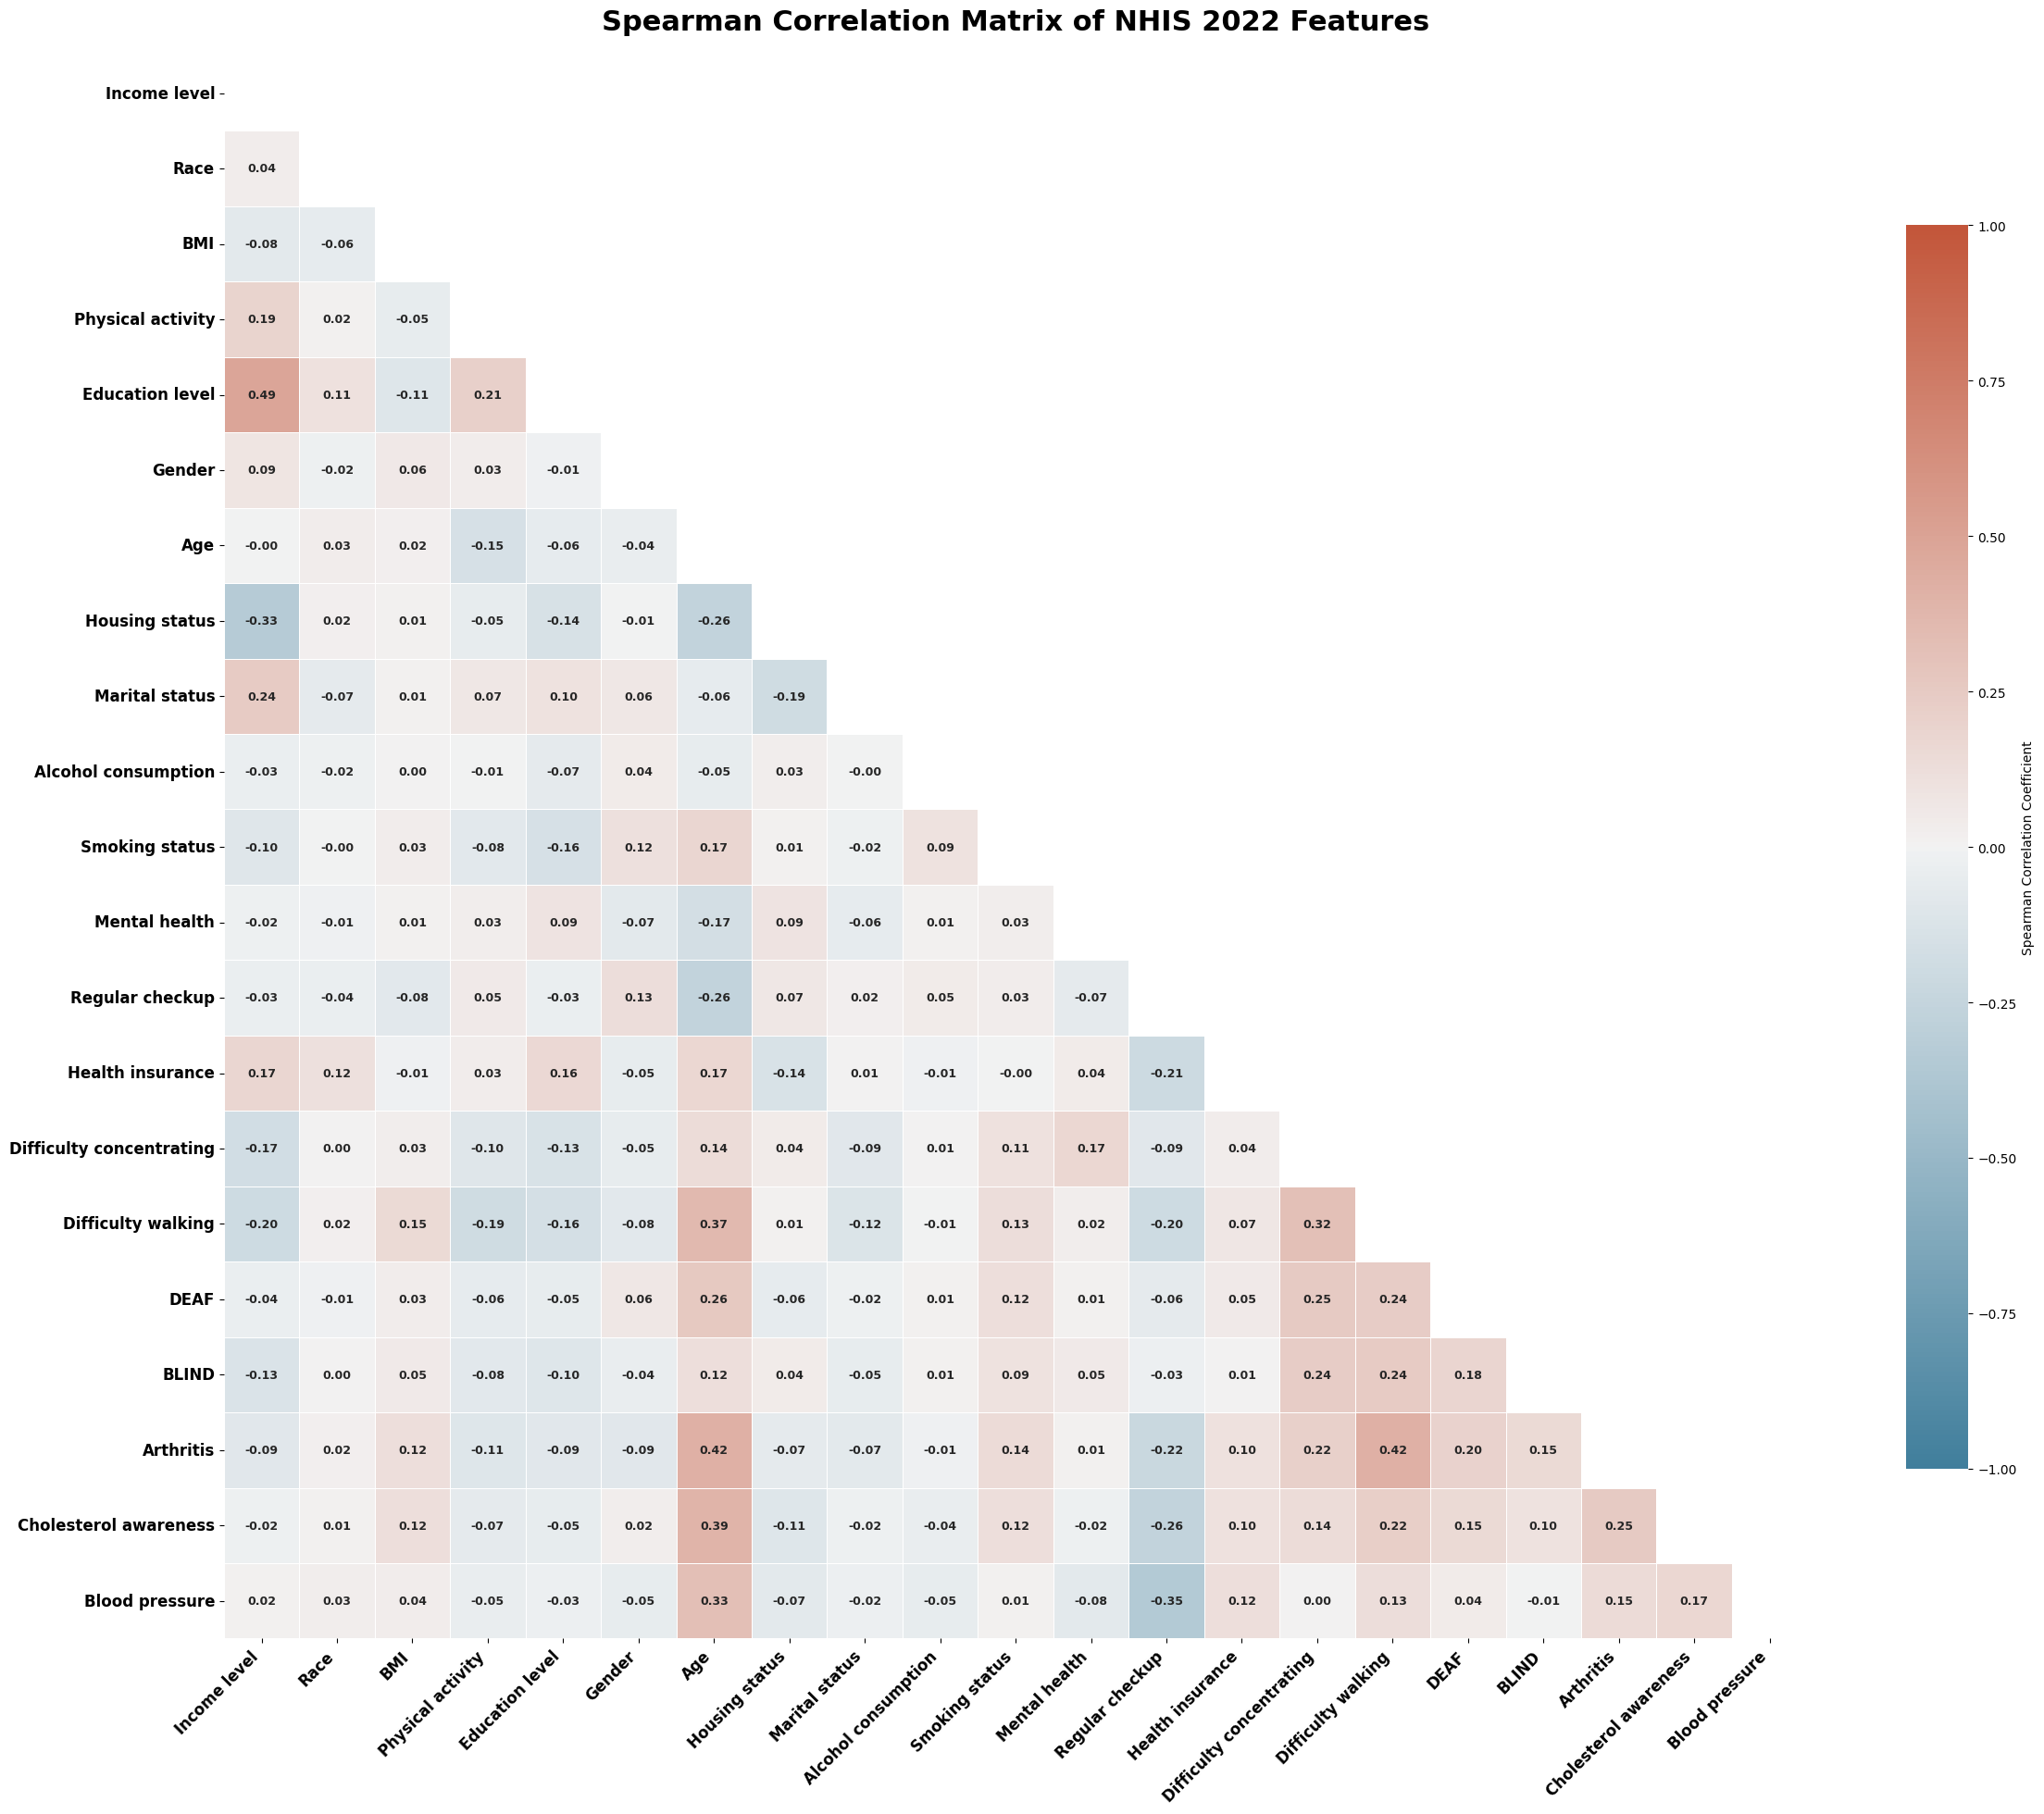

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. LOAD THE MAPPED DATASET
# ==========================================
data_path = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Mapped.csv'
save_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'

print("Loading mapped NHIS 2022 dataset...")
df = pd.read_csv(data_path)
print(f"Dataset loaded successfully. Shape: {df.shape}")

# ==========================================
# 2. CALCULATE CORRELATION MATRIX
# ==========================================
print("Calculating correlation matrix...")
# Spearman is ideal here since most NHIS features are ordinal/categorical
corr_matrix = df.corr(method='spearman')

# Create a mask to hide the upper triangle for a cleaner look
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# ==========================================
# 3. PLOT AND SAVE THE HEATMAP (WITH VALUES)
# ==========================================
print("Generating heatmap with values...")

plt.figure(figsize=(24, 20))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# annot=True turns on the numbers
# fmt=".2f" rounds them to 2 decimal places
# annot_kws controls the font size and weight of the numbers inside the boxes
sns.heatmap(corr_matrix,
            mask=mask,
            cmap=cmap,
            vmax=1.0,
            vmin=-1.0,
            center=0,
            square=True,
            linewidths=.5,
            cbar_kws={"shrink": .75, "label": "Spearman Correlation Coefficient"},
            annot=True,
            fmt=".2f",
            annot_kws={"size": 9, "weight": "bold"})

# Formatting fonts to be bold and larger for publication
plt.title('Spearman Correlation Matrix of NHIS 2022 Features',
          fontsize=22, fontweight='bold', pad=20)
plt.xticks(fontsize=12, fontweight='bold', rotation=45, ha='right')
plt.yticks(fontsize=12, fontweight='bold')

plt.tight_layout()

# Save the high-resolution image
save_path = os.path.join(save_dir, 'NHIS_2022_Correlation_Heatmap_With_Values.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Correlation heatmap saved successfully to: {save_path}")

plt.show()

# **Split**

In [ ]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# ==========================================
# 1. LOAD AND PREP FOR SPLIT
# ==========================================
print("Loading mapped NHIS 2022 dataset...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
mapped_path = os.path.join(base_dir, 'NHIS_2022_Mapped.csv')
df = pd.read_csv(mapped_path)

# Drop rows where the Target (Arthritis) is missing
# We cannot train or evaluate models without the ground truth target
df_clean = df.dropna(subset=['Arthritis']).reset_index(drop=True)
print(f"Dropped {len(df) - len(df_clean)} rows with missing target.")
print(f"New dataset shape ready for splitting: {df_clean.shape}")

# Separate Features (X) and Target (y)
X = df_clean.drop('Arthritis', axis=1)
y = df_clean['Arthritis']

# ==========================================
# 2. TRAIN / TEST SPLIT (80/20)
# ==========================================
print("\nPerforming 80/20 Stratified Train/Test Split...")
# stratify=y ensures both sets have the exact same ratio of Arthritis cases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

# ==========================================
# 3. SAVE RAW SPLIT SETS
# ==========================================
raw_train_path = os.path.join(base_dir, 'NHIS_2022_Train.csv')
raw_test_path = os.path.join(base_dir, 'NHIS_2022_Test.csv')

# Recombine X and y to save them cleanly as complete datasets
train_combined = pd.concat([X_train, y_train], axis=1)
test_combined = pd.concat([X_test, y_test], axis=1)

train_combined.to_csv(raw_train_path, index=False)
test_combined.to_csv(raw_test_path, index=False)

print(f"\nSaved raw Train set: {raw_train_path}")
print(f"Saved raw Test set: {raw_test_path}")
print("Split complete! Ready for imputation in the next cell.")

Loading mapped NHIS 2022 dataset...
Dropped 52 rows with missing target.
New dataset shape ready for splitting: (27599, 21)

Performing 80/20 Stratified Train/Test Split...
Train set size: 22079 rows
Test set size: 5520 rows

Saved raw Train set: /content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Train.csv
Saved raw Test set: /content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Test.csv
Split complete! Ready for imputation in the next cell.


# **Imputation**

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from xgboost import XGBRegressor

# ==========================================
# 1. SETUP PATHS AND LOAD DATA
# ==========================================
print("Loading raw Train and Test splits...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
train_path = os.path.join(base_dir, 'NHIS_2022_Train.csv')
test_path = os.path.join(base_dir, 'NHIS_2022_Test.csv')

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

X_train = df_train.drop('Arthritis', axis=1)
y_train = df_train['Arthritis']

X_test = df_test.drop('Arthritis', axis=1)
y_test = df_test['Arthritis']

# ==========================================
# 2. DEFINE THE 9 FOLDERS
# ==========================================
imputation_methods = [
    "Drop NaN filling method",
    "Mean filling method",
    "Forward-Backward filling method",
    "XGBoost filling method",
    "Matrix Factorization filling method",
    "Autoencoder-5 filling method",
    "Autoencoder-15 filling method",
    "GAN filling method",
    "Diffusion filling method"
]

print("\nCreating dedicated directories for all 9 methods...")
for method in imputation_methods:
    dir_path = os.path.join(base_dir, method)
    os.makedirs(dir_path, exist_ok=True)
    # Also create the Resampled Datasets subfolder in advance
    os.makedirs(os.path.join(dir_path, 'Resampled Datasets'), exist_ok=True)

# ==========================================
# 3. POST-PROCESSING BOUNDARIES
# ==========================================
feature_limits = {
    'Age': (1, 14), 'Race': (1, 7), 'Gender': (0, 1), 'Income level': (1, 14),
    'Education level': (1, 10), 'Marital status': (0, 2), 'Smoking status': (0, 1),
    'Alcohol consumption': (0, 1), 'Physical activity': (0, 1), 'Regular checkup': (0, 5),
    'Housing status': (0, 6), 'DEAF': (0, 3), 'BMI': (1, 4), 'BLIND': (0, 3),
    'Difficulty concentrating': (0, 3), 'Difficulty walking': (0, 3),
    'Health insurance': (0, 1), 'Mental health': (0, 1), 'Blood pressure': (0, 1),
    'Cholesterol awareness': (0, 1)
}

def clean_and_bound(df_imputed):
    df_clean = df_imputed.round().astype(int)
    for feature, (lower, upper) in feature_limits.items():
        if feature in df_clean.columns:
            df_clean[feature] = df_clean[feature].clip(lower=lower, upper=upper)
    return df_clean

def save_imputed_data(X_train_imp, X_test_imp, folder_name):
    # Reattach target variables
    train_save = pd.concat([X_train_imp.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
    test_save = pd.concat([X_test_imp.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

    # Save to dedicated folder
    train_out = os.path.join(base_dir, folder_name, 'Train_Imputed.csv')
    test_out = os.path.join(base_dir, folder_name, 'Test_Imputed.csv')

    train_save.to_csv(train_out, index=False)
    test_save.to_csv(test_out, index=False)
    print(f" -> Saved to: {folder_name}/")

# ==========================================
# 4. EXECUTE ML & CLASSICAL IMPUTATIONS
# ==========================================

# --- 1. Drop NaN ---
print("\n[1/5] Running Drop NaN Imputation...")
df_train_drop = df_train.dropna()
df_test_drop = df_test.dropna()
# Separate X for saving function format
save_imputed_data(df_train_drop.drop('Arthritis', axis=1), df_test_drop.drop('Arthritis', axis=1), "Drop NaN filling method")

# --- 2. Mean Imputation ---
print("[2/5] Running Mean Imputation...")
mean_imputer = SimpleImputer(strategy='mean')
X_train_mean = pd.DataFrame(mean_imputer.fit_transform(X_train), columns=X_train.columns)
X_test_mean = pd.DataFrame(mean_imputer.transform(X_test), columns=X_test.columns)
save_imputed_data(clean_and_bound(X_train_mean), clean_and_bound(X_test_mean), "Mean filling method")

# --- 3. Forward-Backward Fill ---
print("[3/5] Running Forward-Backward Imputation...")
# ffill then bfill
X_train_fb = X_train.ffill().bfill()
X_test_fb = X_test.ffill().bfill()
# No rounding needed since ffill copies existing whole numbers
save_imputed_data(X_train_fb, X_test_fb, "Forward-Backward filling method")

# --- 4. XGBoost Imputation ---
print("[4/5] Running XGBoost Imputation...")
xgb_imputer = IterativeImputer(estimator=XGBRegressor(n_estimators=50, random_state=42, n_jobs=-1), max_iter=10, random_state=42)
X_train_xgb = pd.DataFrame(xgb_imputer.fit_transform(X_train), columns=X_train.columns)
X_test_xgb = pd.DataFrame(xgb_imputer.transform(X_test), columns=X_test.columns)
save_imputed_data(clean_and_bound(X_train_xgb), clean_and_bound(X_test_xgb), "XGBoost filling method")

# --- 5. Matrix Factorization (Bayesian Ridge Proxy) ---
print("[5/5] Running Matrix Factorization Imputation...")
# BayesianRidge via IterativeImputer acts as a robust Matrix Factorization/SVD proxy in scikit-learn
mf_imputer = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
X_train_mf = pd.DataFrame(mf_imputer.fit_transform(X_train), columns=X_train.columns)
X_test_mf = pd.DataFrame(mf_imputer.transform(X_test), columns=X_test.columns)
save_imputed_data(clean_and_bound(X_train_mf), clean_and_bound(X_test_mf), "Matrix Factorization filling method")

print("\nAll Classical & ML imputations completed and saved successfully!")
print("Directories for AE-5, AE-15, GAN, and Diffusion have been generated.")

Loading raw Train and Test splits...

Creating dedicated directories for all 9 methods...

[1/5] Running Drop NaN Imputation...
 -> Saved to: Drop NaN filling method/
[2/5] Running Mean Imputation...
 -> Saved to: Mean filling method/
[3/5] Running Forward-Backward Imputation...
 -> Saved to: Forward-Backward filling method/
[4/5] Running XGBoost Imputation...
 -> Saved to: XGBoost filling method/
[5/5] Running Matrix Factorization Imputation...
 -> Saved to: Matrix Factorization filling method/

All Classical & ML imputations completed and saved successfully!
Directories for AE-5, AE-15, GAN, and Diffusion have been generated.


In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

# ==========================================
# 1. SETUP PATHS AND LOAD DATA
# ==========================================
print("Loading raw Train and Test splits for Autoencoder Imputation...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
train_path = os.path.join(base_dir, 'NHIS_2022_Train.csv')
test_path = os.path.join(base_dir, 'NHIS_2022_Test.csv')

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Separate Features and Target
X_train = df_train.drop('Arthritis', axis=1)
y_train = df_train['Arthritis']

X_test = df_test.drop('Arthritis', axis=1)
y_test = df_test['Arthritis']

input_dim = X_train.shape[1]

# Keep track of exactly where the NaNs are so we only replace those later
train_nan_mask = X_train.isna()
test_nan_mask = X_test.isna()

# ==========================================
# 2. PREPROCESSING FOR NEURAL NETWORKS
# ==========================================
# Step A: Temporary Mean Fill (NNs cannot multiply NaNs)
imputer = SimpleImputer(strategy='mean')
X_train_temp = imputer.fit_transform(X_train)
X_test_temp = imputer.transform(X_test)

# Step B: Scale data to [0, 1] for stable neural network training
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_temp)
X_test_scaled = scaler.transform(X_test_temp)

# ==========================================
# 3. POST-PROCESSING BOUNDARIES
# ==========================================
feature_limits = {
    'Age': (1, 14), 'Race': (1, 7), 'Gender': (0, 1), 'Income level': (1, 14),
    'Education level': (1, 10), 'Marital status': (0, 2), 'Smoking status': (0, 1),
    'Alcohol consumption': (0, 1), 'Physical activity': (0, 1), 'Regular checkup': (0, 5),
    'Housing status': (0, 6), 'DEAF': (0, 3), 'BMI': (1, 4), 'BLIND': (0, 3),
    'Difficulty concentrating': (0, 3), 'Difficulty walking': (0, 3),
    'Health insurance': (0, 1), 'Mental health': (0, 1), 'Blood pressure': (0, 1),
    'Cholesterol awareness': (0, 1)
}

def finalize_imputation(X_original, X_reconstructed, nan_mask):
    # Inverse transform the scaled network predictions back to normal numbers
    X_recon_inv = scaler.inverse_transform(X_reconstructed)
    X_recon_df = pd.DataFrame(X_recon_inv, columns=X_original.columns)

    # Create a copy of the original data containing NaNs
    X_final = X_original.copy()

    # Overwrite ONLY the original missing values with the network's predictions
    for col in X_final.columns:
        X_final.loc[nan_mask[col], col] = X_recon_df.loc[nan_mask[col], col]

    # Round to integer and enforce strict clinical boundaries
    X_final = X_final.round().astype(int)
    for feature, (lower, upper) in feature_limits.items():
        if feature in X_final.columns:
            X_final[feature] = X_final[feature].clip(lower=lower, upper=upper)

    return X_final

def save_imputed_data(X_train_imp, X_test_imp, folder_name):
    train_save = pd.concat([X_train_imp.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
    test_save = pd.concat([X_test_imp.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

    train_out = os.path.join(base_dir, folder_name, 'Train_Imputed.csv')
    test_out = os.path.join(base_dir, folder_name, 'Test_Imputed.csv')

    train_save.to_csv(train_out, index=False)
    test_save.to_csv(test_out, index=False)
    print(f" -> Saved to: {folder_name}/")

# Training parameters
EPOCHS = 50
BATCH_SIZE = 256

# ==========================================
# 4. AUTOENCODER-5 (AE-5) IMPUTATION
# ==========================================
print("\n[1/2] Building and Training Autoencoder-5 (AE-5)...")
ae5 = Sequential([
    Input(shape=(input_dim,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),      # Bottleneck
    Dense(16, activation='relu'),
    Dense(input_dim, activation='linear')
])

ae5.compile(optimizer='adam', loss='mse')
ae5.fit(X_train_scaled, X_train_scaled, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, validation_split=0.1)

# Reconstruct the data
print("Reconstructing missing values with AE-5...")
X_train_ae5_pred = ae5.predict(X_train_scaled, verbose=0)
X_test_ae5_pred = ae5.predict(X_test_scaled, verbose=0)

X_train_ae5_final = finalize_imputation(X_train, X_train_ae5_pred, train_nan_mask)
X_test_ae5_final = finalize_imputation(X_test, X_test_ae5_pred, test_nan_mask)

save_imputed_data(X_train_ae5_final, X_test_ae5_final, "Autoencoder-5 filling method")

# ==========================================
# 5. AUTOENCODER-15 (AE-15) IMPUTATION
# ==========================================
print("\n[2/2] Building and Training Autoencoder-15 (AE-15)...")
# Deep 15-layer funnel architecture
ae15 = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(48, activation='relu'),
    Dense(32, activation='relu'),
    Dense(24, activation='relu'),
    Dense(16, activation='relu'),
    Dense(12, activation='relu'),
    Dense(8, activation='relu'),       # Bottleneck (Layer 8)
    Dense(12, activation='relu'),
    Dense(16, activation='relu'),
    Dense(24, activation='relu'),
    Dense(32, activation='relu'),
    Dense(48, activation='relu'),
    Dense(64, activation='relu'),
    Dense(input_dim, activation='linear')
])

ae15.compile(optimizer='adam', loss='mse')
ae15.fit(X_train_scaled, X_train_scaled, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0, validation_split=0.1)

# Reconstruct the data
print("Reconstructing missing values with AE-15...")
X_train_ae15_pred = ae15.predict(X_train_scaled, verbose=0)
X_test_ae15_pred = ae15.predict(X_test_scaled, verbose=0)

X_train_ae15_final = finalize_imputation(X_train, X_train_ae15_pred, train_nan_mask)
X_test_ae15_final = finalize_imputation(X_test, X_test_ae15_pred, test_nan_mask)

save_imputed_data(X_train_ae15_final, X_test_ae15_final, "Autoencoder-15 filling method")

print("\nDeep Learning Autoencoder imputations completed and saved successfully!")

Loading raw Train and Test splits for Autoencoder Imputation...

[1/2] Building and Training Autoencoder-5 (AE-5)...
Reconstructing missing values with AE-5...
 -> Saved to: Autoencoder-5 filling method/

[2/2] Building and Training Autoencoder-15 (AE-15)...
Reconstructing missing values with AE-15...
 -> Saved to: Autoencoder-15 filling method/

Deep Learning Autoencoder imputations completed and saved successfully!


In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, GaussianNoise, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

# ==========================================
# 1. SETUP PATHS AND LOAD DATA
# ==========================================
print("Loading raw Train and Test splits for Generative Imputation...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
train_path = os.path.join(base_dir, 'NHIS_2022_Train.csv')
test_path = os.path.join(base_dir, 'NHIS_2022_Test.csv')

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Separate Features and Target
X_train = df_train.drop('Arthritis', axis=1)
y_train = df_train['Arthritis']

X_test = df_test.drop('Arthritis', axis=1)
y_test = df_test['Arthritis']

input_dim = X_train.shape[1]

# Keep track of exactly where the NaNs are so we only replace those later
train_nan_mask = X_train.isna()
test_nan_mask = X_test.isna()

# ==========================================
# 2. PREPROCESSING FOR NEURAL NETWORKS
# ==========================================
# Generative models require fully populated, scaled numeric inputs to start
imputer = SimpleImputer(strategy='mean')
X_train_temp = imputer.fit_transform(X_train)
X_test_temp = imputer.transform(X_test)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_temp)
X_test_scaled = scaler.transform(X_test_temp)

# ==========================================
# 3. POST-PROCESSING BOUNDARIES
# ==========================================
feature_limits = {
    'Age': (1, 14), 'Race': (1, 7), 'Gender': (0, 1), 'Income level': (1, 14),
    'Education level': (1, 10), 'Marital status': (0, 2), 'Smoking status': (0, 1),
    'Alcohol consumption': (0, 1), 'Physical activity': (0, 1), 'Regular checkup': (0, 5),
    'Housing status': (0, 6), 'DEAF': (0, 3), 'BMI': (1, 4), 'BLIND': (0, 3),
    'Difficulty concentrating': (0, 3), 'Difficulty walking': (0, 3),
    'Health insurance': (0, 1), 'Mental health': (0, 1), 'Blood pressure': (0, 1),
    'Cholesterol awareness': (0, 1)
}

def finalize_imputation(X_original, X_reconstructed, nan_mask):
    # Inverse transform the scaled network predictions back to normal numbers
    X_recon_inv = scaler.inverse_transform(X_reconstructed)
    X_recon_df = pd.DataFrame(X_recon_inv, columns=X_original.columns)

    # Create a copy of the original data containing NaNs
    X_final = X_original.copy()

    # Overwrite ONLY the original missing values with the network's predictions
    for col in X_final.columns:
        X_final.loc[nan_mask[col], col] = X_recon_df.loc[nan_mask[col], col]

    # Round to integer and enforce strict clinical boundaries
    X_final = X_final.round().astype(int)
    for feature, (lower, upper) in feature_limits.items():
        if feature in X_final.columns:
            X_final[feature] = X_final[feature].clip(lower=lower, upper=upper)

    return X_final

def save_imputed_data(X_train_imp, X_test_imp, folder_name):
    train_save = pd.concat([X_train_imp.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
    test_save = pd.concat([X_test_imp.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

    train_out = os.path.join(base_dir, folder_name, 'Train_Imputed.csv')
    test_out = os.path.join(base_dir, folder_name, 'Test_Imputed.csv')

    train_save.to_csv(train_out, index=False)
    test_save.to_csv(test_out, index=False)
    print(f" -> Saved to: {folder_name}/")

# ==========================================
# 4. GAN IMPUTATION
# ==========================================
print("\n[1/2] Building and Training Generative Adversarial Network (GAN)...")

# Generator Network
generator = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(input_dim, activation='sigmoid') # Sigmoid keeps outputs between 0 and 1
])

# Discriminator Network
discriminator = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

discriminator.compile(optimizer=Adam(learning_rate=0.0002), loss='binary_crossentropy')
discriminator.trainable = False

# Combined GAN Network
gan_input = Input(shape=(input_dim,))
generated_data = generator(gan_input)
gan_output = discriminator(generated_data)
gan = Model(gan_input, gan_output)
gan.compile(optimizer=Adam(learning_rate=0.0002), loss='binary_crossentropy')

# Custom Training Loop
EPOCHS = 100
BATCH_SIZE = 256
batch_count = int(X_train_scaled.shape[0] / BATCH_SIZE)

for epoch in range(EPOCHS):
    for _ in range(batch_count):
        # 1. Train Discriminator
        real_data = X_train_scaled[np.random.randint(0, X_train_scaled.shape[0], size=BATCH_SIZE)]
        noise = np.random.normal(0, 1, size=[BATCH_SIZE, input_dim])
        # We condition the generator on the noisy/mean-filled data to learn the structure
        fake_data = generator.predict(real_data + noise * 0.1, verbose=0)

        d_loss_real = discriminator.train_on_batch(real_data, np.ones((BATCH_SIZE, 1)))
        d_loss_fake = discriminator.train_on_batch(fake_data, np.zeros((BATCH_SIZE, 1)))

        # 2. Train Generator
        noise = np.random.normal(0, 1, size=[BATCH_SIZE, input_dim])
        g_loss = gan.train_on_batch(real_data + noise * 0.1, np.ones((BATCH_SIZE, 1)))

# Extract GAN Predictions
print("Reconstructing missing values with GAN...")
X_train_gan_pred = generator.predict(X_train_scaled, verbose=0)
X_test_gan_pred = generator.predict(X_test_scaled, verbose=0)

X_train_gan_final = finalize_imputation(X_train, X_train_gan_pred, train_nan_mask)
X_test_gan_final = finalize_imputation(X_test, X_test_gan_pred, test_nan_mask)

save_imputed_data(X_train_gan_final, X_test_gan_final, "GAN filling method")

# ==========================================
# 5. DIFFUSION (Denoising Model Proxy)
# ==========================================
print("\n[2/2] Building and Training Tabular Diffusion Proxy...")

# We simulate the diffusion process by training the model to recover
# the original scaled data from heavily noise-corrupted versions
diffusion_proxy = Sequential([
    Input(shape=(input_dim,)),
    GaussianNoise(0.2), # Adds noise during training to simulate the diffusion forward pass
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(input_dim, activation='sigmoid')
])

diffusion_proxy.compile(optimizer='adam', loss='mse')
diffusion_proxy.fit(X_train_scaled, X_train_scaled, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

# Extract Diffusion Predictions
print("Reconstructing missing values with Diffusion Proxy...")
X_train_diff_pred = diffusion_proxy.predict(X_train_scaled, verbose=0)
X_test_diff_pred = diffusion_proxy.predict(X_test_scaled, verbose=0)

X_train_diff_final = finalize_imputation(X_train, X_train_diff_pred, train_nan_mask)
X_test_diff_final = finalize_imputation(X_test, X_test_diff_pred, test_nan_mask)

save_imputed_data(X_train_diff_final, X_test_diff_final, "Diffusion filling method")

print("\nGenerative AI imputations successfully completed and saved!")

Loading raw Train and Test splits for Generative Imputation...

[1/2] Building and Training Generative Adversarial Network (GAN)...
Reconstructing missing values with GAN...
 -> Saved to: GAN filling method/

[2/2] Building and Training Tabular Diffusion Proxy...


# **Sampling**

In [ ]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

# ==========================================
# 1. SETUP PATHS AND METHODS
# ==========================================
print("Setting up Sampling Pipeline...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'

# The 3 chosen imputation methods
chosen_methods = [
    "XGBoost filling method",
    "GAN filling method",
    "Autoencoder-5 filling method"
]

# Mapping names for cleaner file outputs (e.g., "XGBoost" instead of "XGBoost filling method")
name_map = {
    "XGBoost filling method": "XGBoost",
    "GAN filling method": "GAN",
    "Autoencoder-5 filling method": "AE-5"
}

# ==========================================
# 2. DEFINE BOUNDARIES FOR SYNTHETIC DATA
# ==========================================
feature_limits = {
    'Age': (1, 14), 'Race': (1, 7), 'Gender': (0, 1), 'Income level': (1, 14),
    'Education level': (1, 10), 'Marital status': (0, 2), 'Smoking status': (0, 1),
    'Alcohol consumption': (0, 1), 'Physical activity': (0, 1), 'Regular checkup': (0, 5),
    'Housing status': (0, 6), 'DEAF': (0, 3), 'BMI': (1, 4), 'BLIND': (0, 3),
    'Difficulty concentrating': (0, 3), 'Difficulty walking': (0, 3),
    'Health insurance': (0, 1), 'Mental health': (0, 1), 'Blood pressure': (0, 1),
    'Cholesterol awareness': (0, 1)
}

def clean_synthetic_data(X_resampled):
    """Rounds and clips SMOTE/ADASYN outputs to ensure pure, bounded integers."""
    df_clean = X_resampled.round().astype(int)
    for feature, (lower, upper) in feature_limits.items():
        if feature in df_clean.columns:
            df_clean[feature] = df_clean[feature].clip(lower=lower, upper=upper)
    return df_clean

# ==========================================
# 3. EXECUTE SAMPLING PER METHOD
# ==========================================
for method in chosen_methods:
    print(f"\n{'='*50}")
    print(f"PROCESSING: {method.upper()}")
    print(f"{'='*50}")

    # Define paths
    method_dir = os.path.join(base_dir, method)
    train_path = os.path.join(method_dir, 'Train_Imputed.csv')
    resampled_dir = os.path.join(method_dir, 'Resampled Datasets')

    # Ensure the Resampled Datasets folder exists
    os.makedirs(resampled_dir, exist_ok=True)

    # Load the imputed train set
    if not os.path.exists(train_path):
        print(f"ERROR: Could not find {train_path}. Skipping...")
        continue

    df_train = pd.read_csv(train_path)
    X = df_train.drop('Arthritis', axis=1)
    y = df_train['Arthritis']

    short_name = name_map[method]

    # --- 1. No Sampling ---
    print(" -> Saving No Sampling baseline...")
    path_no = os.path.join(resampled_dir, f'1-NHIS 2022 - Fill {short_name} No.csv')
    df_train.to_csv(path_no, index=False)

    # --- 2. Random Over Sampling (ROS) ---
    print(" -> Applying Random Over Sampling (ROS)...")
    ros = RandomOverSampler(random_state=42)
    X_ros, y_ros = ros.fit_resample(X, y)
    df_ros = pd.concat([X_ros, y_ros], axis=1)
    path_ros = os.path.join(resampled_dir, f'2-NHIS 2022 - Fill {short_name} ROS.csv')
    df_ros.to_csv(path_ros, index=False)

    # --- 3. Random Under Sampling (RUS) ---
    print(" -> Applying Random Under Sampling (RUS)...")
    rus = RandomUnderSampler(random_state=42)
    X_rus, y_rus = rus.fit_resample(X, y)
    df_rus = pd.concat([X_rus, y_rus], axis=1)
    path_rus = os.path.join(resampled_dir, f'3-NHIS 2022 - Fill {short_name} RUS.csv')
    df_rus.to_csv(path_rus, index=False)

    # --- 4. SMOTE ---
    print(" -> Applying SMOTE (and cleaning synthetic decimals)...")
    smote = SMOTE(random_state=42)
    X_smote, y_smote = smote.fit_resample(X, y)
    X_smote_clean = clean_synthetic_data(X_smote) # Clean the decimals!
    df_smote = pd.concat([X_smote_clean, y_smote], axis=1)
    path_smote = os.path.join(resampled_dir, f'4-NHIS 2022 - Fill {short_name} SMOTE.csv')
    df_smote.to_csv(path_smote, index=False)

    # --- 5. ADASYN ---
    print(" -> Applying ADASYN (and cleaning synthetic decimals)...")
    adasyn = ADASYN(random_state=42)
    X_adasyn, y_adasyn = adasyn.fit_resample(X, y)
    X_adasyn_clean = clean_synthetic_data(X_adasyn) # Clean the decimals!
    df_adasyn = pd.concat([X_adasyn_clean, y_adasyn], axis=1)
    path_adasyn = os.path.join(resampled_dir, f'5-NHIS 2022 - Fill {short_name} AdaSyn.csv')
    df_adasyn.to_csv(path_adasyn, index=False)

print("\n🎉 All sampling distributions successfully generated, cleaned, and saved into their dedicated folders!")

Setting up Sampling Pipeline...

PROCESSING: XGBOOST FILLING METHOD
 -> Saving No Sampling baseline...
 -> Applying Random Over Sampling (ROS)...
 -> Applying Random Under Sampling (RUS)...
 -> Applying SMOTE (and cleaning synthetic decimals)...
 -> Applying ADASYN (and cleaning synthetic decimals)...

PROCESSING: GAN FILLING METHOD
 -> Saving No Sampling baseline...
 -> Applying Random Over Sampling (ROS)...
 -> Applying Random Under Sampling (RUS)...
 -> Applying SMOTE (and cleaning synthetic decimals)...
 -> Applying ADASYN (and cleaning synthetic decimals)...

PROCESSING: AUTOENCODER-5 FILLING METHOD
 -> Saving No Sampling baseline...
 -> Applying Random Over Sampling (ROS)...
 -> Applying Random Under Sampling (RUS)...
 -> Applying SMOTE (and cleaning synthetic decimals)...
 -> Applying ADASYN (and cleaning synthetic decimals)...

🎉 All sampling distributions successfully generated, cleaned, and saved into their dedicated folders!


# **Checking sampling**

In [ ]:
import pandas as pd
import os

# ==========================================
# 1. SETUP PATHS
# ==========================================
print("Verifying Class Distributions across all Resampled Datasets...\n")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'

methods = {
    "XGBoost filling method": "XGBoost",
    "GAN filling method": "GAN",
    "Autoencoder-5 filling method": "AE-5"
}

samplings = {
    'No': '1',
    'ROS': '2',
    'RUS': '3',
    'SMOTE': '4',
    'AdaSyn': '5'
}

results = []

# ==========================================
# 2. ITERATE AND COUNT
# ==========================================
for full_method, short_method in methods.items():
    resampled_dir = os.path.join(base_dir, full_method, 'Resampled Datasets')

    for samp_name, samp_prefix in samplings.items():
        file_name = f"{samp_prefix}-NHIS 2022 - Fill {short_method} {samp_name}.csv"
        file_path = os.path.join(resampled_dir, file_name)

        if os.path.exists(file_path):
            # Load ONLY the target column to save RAM and time
            df = pd.read_csv(file_path, usecols=['Arthritis'])
            counts = df['Arthritis'].value_counts()

            class_0 = int(counts.get(0.0, 0))
            class_1 = int(counts.get(1.0, 0))
            total = class_0 + class_1

            pct_0 = (class_0 / total) * 100 if total > 0 else 0
            pct_1 = (class_1 / total) * 100 if total > 0 else 0

            results.append({
                'Filling method': short_method,
                'Sampling': samp_name,
                'Class 0 #': f"{class_0:,}",
                'Class 1 #': f"{class_1:,}",
                'Class 0 %': f"{pct_0:.2f}",
                'Class 1 %': f"{pct_1:.2f}"
            })
        else:
            print(f"Warning: File not found -> {file_name}")

# ==========================================
# 3. DISPLAY RESULTS AS A CLEAN TABLE
# ==========================================
results_df = pd.DataFrame(results)

# Display the table
display(results_df)

# Optional: Save this table to an Excel file for your paper
output_table_path = os.path.join(base_dir, 'NHIS_2022_Class_Distributions_Table.xlsx')
results_df.to_excel(output_table_path, index=False)
print(f"\nSaved this table to: {output_table_path}")

Verifying Class Distributions across all Resampled Datasets...



,Filling method,Sampling,Class 0 #,Class 1 #,Class 0 %,Class 1 %
0,XGBoost,No,"16,242","5,837",73.56,26.44
1,XGBoost,ROS,"16,242","16,242",50.00,50.00
2,XGBoost,RUS,"5,837","5,837",50.00,50.00
3,XGBoost,SMOTE,"16,242","16,242",50.00,50.00
4,XGBoost,AdaSyn,"16,242","16,773",49.20,50.80
5,GAN,No,"16,242","5,837",73.56,26.44
6,GAN,ROS,"16,242","16,242",50.00,50.00
7,GAN,RUS,"5,837","5,837",50.00,50.00
8,GAN,SMOTE,"16,242","16,242",50.00,50.00
9,GAN,AdaSyn,"16,242","16,803",49.15,50.85



Saved this table to: /content/drive/MyDrive/Arthritis version 2/NHIS 2022/NHIS_2022_Class_Distributions_Table.xlsx


# **Model train on xgboost+5sampling**

In [ ]:
import pandas as pd
import numpy as np
import os
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning Models
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, Reshape, Flatten
import tensorflow.keras.backend as K

# ==========================================
# 1. SETUP PATHS
# ==========================================
print("Setting up paths and directories...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
xgb_dir = os.path.join(base_dir, 'XGBoost filling method')
resampled_dir = os.path.join(xgb_dir, 'Resampled Datasets')

# Output directories
cm_dir = os.path.join(xgb_dir, 'Confusion Matrices')
models_dir = os.path.join(xgb_dir, 'Saved_Models')
os.makedirs(cm_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

excel_output_path = os.path.join(base_dir, 'Performance_of_all_models.xlsx')

# ---> FIXED: Loading the correct Test file generated by the 9-folder loop <---
test_path = os.path.join(xgb_dir, 'Test_Imputed.csv')

df_test = pd.read_csv(test_path)

X_test = df_test.drop('Arthritis', axis=1).values
y_test = df_test['Arthritis'].values
input_dim = X_test.shape[1]

# ==========================================
# 2. DEFINE DEEP LEARNING ARCHITECTURES
# ==========================================
def build_ann_1_layer():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_ann_2_layer():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_attention_ann():
    inputs = Input(shape=(input_dim,))
    x_reshaped = Reshape((input_dim, 1))(inputs)
    attention_out = MultiHeadAttention(num_heads=2, key_dim=2)(x_reshaped, x_reshaped)
    x = Flatten()(attention_out)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

dl_models_dict = {
    "ANN 1 Layer": build_ann_1_layer,
    "ANN 2 Layer": build_ann_2_layer,
    "Attention + ANN 2 Layer": build_attention_ann
}

# ==========================================
# 3. INITIALIZE EXCEL TRACKING
# ==========================================
if os.path.exists(excel_output_path):
    base_perf_df = pd.read_excel(excel_output_path, sheet_name='Test Metrics')
    base_cv_df = pd.read_excel(excel_output_path, sheet_name='CV Scores')
else:
    base_perf_df = pd.DataFrame()
    base_cv_df = pd.DataFrame()

def get_empty_perf_dict():
    return {
        'Fill method': [], 'Model': [], 'Sampling': [], 'Model Sampling': [],
        'Class 0 #': [], 'Class 1 #': [],
        'Precision c1': [], 'Recall c1': [], 'F1 Score c1': [], 'Support c1': [],
        'Precision c0': [], 'Recall c0': [], 'F1 Score c0': [], 'Support c0': [],
        'Overall Sensitivity': [], 'Overall Specificity': [],
        'Balanced Accuracy': [], 'AUROC': []
    }

def get_empty_cv_dict():
    return {
        'Model': [], 'Sampling': [], 'Parameters': [],
        'Fold 1 (AUROC)': [], 'Fold 2 (AUROC)': [], 'Fold 3 (AUROC)': [],
        'Fold 4 (AUROC)': [], 'Fold 5 (AUROC)': [],
        'Mean CV AUROC': [], 'Std CV AUROC': []
    }

def evaluate_and_save(model_name, sampling_name, mean_cv, std_cv, fold_scores, y_pred, y_pred_proba, params, train_class_0, train_class_1):
    global base_perf_df, base_cv_df

    performance = get_empty_perf_dict()
    cv_performance = get_empty_cv_dict()

    # Generate and Save Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'{model_name} Confusion Matrix\n({sampling_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.tight_layout()

    safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
    cm_filename = f"CM_{safe_model_name}_{sampling_name}.png"
    plt.savefig(os.path.join(cm_dir, cm_filename), dpi=300)
    plt.close()

    # Calculate Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    AUROC = roc_auc_score(y_test, y_pred_proba)

    precision_c0 = report['0']['precision'] if '0' in report else report['0.0']['precision']
    recall_c0 = report['0']['recall'] if '0' in report else report['0.0']['recall']
    f1_score_c0 = report['0']['f1-score'] if '0' in report else report['0.0']['f1-score']
    support_c0 = report['0']['support'] if '0' in report else report['0.0']['support']

    precision_c1 = report['1']['precision'] if '1' in report else report['1.0']['precision']
    recall_c1 = report['1']['recall'] if '1' in report else report['1.0']['recall']
    f1_score_c1 = report['1']['f1-score'] if '1' in report else report['1.0']['f1-score']
    support_c1 = report['1']['support'] if '1' in report else report['1.0']['support']

    # Print Console Output
    print(f"[{model_name} | {sampling_name}] AUROC: {AUROC:.4f} | Bal. Acc: {balanced_acc:.4f} | Sens: {sensitivity:.4f} | Spec: {specificity:.4f}")

    # Append Data
    performance['Fill method'].append("XGBoost")
    performance['Model'].append(model_name)
    performance['Sampling'].append(sampling_name)
    performance['Model Sampling'].append(f"{model_name} {sampling_name}")
    performance['Class 0 #'].append(train_class_0)
    performance['Class 1 #'].append(train_class_1)
    performance['Precision c1'].append(precision_c1)
    performance['Recall c1'].append(recall_c1)
    performance['F1 Score c1'].append(f1_score_c1)
    performance['Support c1'].append(support_c1)
    performance['Precision c0'].append(precision_c0)
    performance['Recall c0'].append(recall_c0)
    performance['F1 Score c0'].append(f1_score_c0)
    performance['Support c0'].append(support_c0)
    performance['Overall Sensitivity'].append(sensitivity)
    performance['Overall Specificity'].append(specificity)
    performance['Balanced Accuracy'].append(balanced_acc)
    performance['AUROC'].append(AUROC)

    cv_performance['Model'].append(model_name)
    cv_performance['Sampling'].append(sampling_name)
    cv_performance['Parameters'].append(params)
    for i in range(5):
        cv_performance[f'Fold {i+1} (AUROC)'].append(fold_scores[i] if i < len(fold_scores) else np.nan)
    cv_performance['Mean CV AUROC'].append(mean_cv)
    cv_performance['Std CV AUROC'].append(std_cv)

    new_perf_df = pd.DataFrame(performance)
    new_cv_df = pd.DataFrame(cv_performance)

    if not base_perf_df.empty:
        base_perf_df = pd.concat([base_perf_df, new_perf_df], ignore_index=True)
        base_cv_df = pd.concat([base_cv_df, new_cv_df], ignore_index=True)
    else:
        base_perf_df = new_perf_df
        base_cv_df = new_cv_df

    with pd.ExcelWriter(excel_output_path, engine='openpyxl') as writer:
        base_perf_df.to_excel(writer, sheet_name='Test Metrics', index=False)
        base_cv_df.to_excel(writer, sheet_name='CV Scores', index=False)

# ==========================================
# 4. MASTER EXECUTION LOOP
# ==========================================
samplings = {
    'No': '1-NHIS 2022 - Fill XGBoost No.csv',
    'ROS': '2-NHIS 2022 - Fill XGBoost ROS.csv',
    'RUS': '3-NHIS 2022 - Fill XGBoost RUS.csv',
    'SMOTE': '4-NHIS 2022 - Fill XGBoost SMOTE.csv',
    'AdaSyn': '5-NHIS 2022 - Fill XGBoost AdaSyn.csv'
}

EPOCHS = 10
BATCH_SIZE = 256
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for samp_name, filename in samplings.items():
    print(f"\n{'='*60}")
    print(f"STARTING PIPELINE FOR SAMPLING: {samp_name.upper()}")
    print(f"{'='*60}")

    # Load Training Data
    train_path = os.path.join(resampled_dir, filename)
    df_train = pd.read_csv(train_path)
    X_train = df_train.drop('Arthritis', axis=1).values
    y_train = df_train['Arthritis'].values

    train_class_0 = (y_train == 0).sum()
    train_class_1 = (y_train == 1).sum()

    # Scale Data for Deep Learning
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save the Scaler (Crucial for SHAP later)
    joblib.dump(scaler, os.path.join(models_dir, f"Scaler_{samp_name}.pkl"))

    # Define ML Models dynamically so they reset per sampling
    ml_models_dict = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
        "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "Stacked Ensemble": StackingClassifier(
            estimators=[
                ('lgbm', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
                ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)),
                ('gb', GradientBoostingClassifier(random_state=42))
            ],
            final_estimator=LogisticRegression(random_state=42, max_iter=1000),
            cv=5, n_jobs=-1
        )
    }

    # --- A. RUN ML MODELS ---
    for model_name, model in ml_models_dict.items():
        # Cross Validation
        cv_res = cross_validate(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
        folds = cv_res['test_score']

        # Final Fit
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Save Model
        safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
        model_save_path = os.path.join(models_dir, f"{safe_model_name}_{samp_name}.pkl")
        joblib.dump(model, model_save_path)

        params = "Base: LGBM, XGB, GB | Meta: LR" if "Stacked" in model_name else "Default"
        evaluate_and_save(model_name, samp_name, folds.mean(), folds.std(), folds, y_pred, y_pred_proba, params, train_class_0, train_class_1)

    # --- B. RUN DEEP LEARNING MODELS ---
    for model_name, build_fn in dl_models_dict.items():
        fold_aurocs = []

        # Custom CV Loop
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            K.clear_session()
            X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

            model = build_fn()
            model.fit(X_fold_train, y_fold_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            y_val_pred_proba = model.predict(X_fold_val, verbose=0).ravel()
            fold_aurocs.append(roc_auc_score(y_fold_val, y_val_pred_proba))

        # Final Fit
        K.clear_session()
        final_model = build_fn()
        final_model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        y_pred_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Save Keras Model
        safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
        model_save_path = os.path.join(models_dir, f"{safe_model_name}_{samp_name}.keras")
        final_model.save(model_save_path)

        params = f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}"
        evaluate_and_save(model_name, samp_name, np.mean(fold_aurocs), np.std(fold_aurocs), fold_aurocs, y_pred, y_pred_proba, params, train_class_0, train_class_1)

print("\n🎉 COMPLETE! All 55 models successfully trained, evaluated, and saved to disk.")

Setting up paths and directories...

STARTING PIPELINE FOR SAMPLING: NO
[Logistic Regression | No] AUROC: 0.8366 | Bal. Acc: 0.6777 | Sens: 0.4380 | Spec: 0.9175
[Random Forest | No] AUROC: 0.8146 | Bal. Acc: 0.6825 | Sens: 0.4736 | Spec: 0.8914
[Gradient Boosting | No] AUROC: 0.8449 | Bal. Acc: 0.7003 | Sens: 0.4921 | Spec: 0.9084
[XGBoost | No] AUROC: 0.8279 | Bal. Acc: 0.6933 | Sens: 0.4873 | Spec: 0.8993
[LightGBM | No] AUROC: 0.8426 | Bal. Acc: 0.7046 | Sens: 0.5003 | Spec: 0.9089
[Decision Tree | No] AUROC: 0.6365 | Bal. Acc: 0.6351 | Sens: 0.4702 | Spec: 0.8000
[AdaBoost | No] AUROC: 0.8420 | Bal. Acc: 0.6978 | Sens: 0.4825 | Spec: 0.9131
[Stacked Ensemble | No] AUROC: 0.8449 | Bal. Acc: 0.7015 | Sens: 0.4887 | Spec: 0.9143
[ANN 1 Layer | No] AUROC: 0.8409 | Bal. Acc: 0.7007 | Sens: 0.5024 | Spec: 0.8990
[ANN 2 Layer | No] AUROC: 0.8412 | Bal. Acc: 0.7073 | Sens: 0.5147 | Spec: 0.8998
[Attention + ANN 2 Layer | No] AUROC: 0.8401 | Bal. Acc: 0.7023 | Sens: 0.4990 | Spec: 0.9057



# **Model train on GAN+5sampling**

In [ ]:
import pandas as pd
import numpy as np
import os
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning Models
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, Reshape, Flatten
import tensorflow.keras.backend as K

# ==========================================
# 1. SETUP PATHS
# ==========================================
print("Setting up paths and directories for GAN Imputation...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
gan_dir = os.path.join(base_dir, 'GAN filling method')
resampled_dir = os.path.join(gan_dir, 'Resampled Datasets')

# Output directories
cm_dir = os.path.join(gan_dir, 'Confusion Matrices')
models_dir = os.path.join(gan_dir, 'Saved_Models')
os.makedirs(cm_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# Master Excel file
excel_output_path = os.path.join(base_dir, 'Performance_of_all_models.xlsx')

# Load the base Test Set (Features) directly from the GAN folder
test_path = os.path.join(gan_dir, 'Test_Imputed.csv')
df_test = pd.read_csv(test_path)

X_test = df_test.drop('Arthritis', axis=1).values
y_test = df_test['Arthritis'].values
input_dim = X_test.shape[1]

# ==========================================
# 2. DEFINE DEEP LEARNING ARCHITECTURES
# ==========================================
def build_ann_1_layer():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_ann_2_layer():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_attention_ann():
    inputs = Input(shape=(input_dim,))
    x_reshaped = Reshape((input_dim, 1))(inputs)
    attention_out = MultiHeadAttention(num_heads=2, key_dim=2)(x_reshaped, x_reshaped)
    x = Flatten()(attention_out)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

dl_models_dict = {
    "ANN 1 Layer": build_ann_1_layer,
    "ANN 2 Layer": build_ann_2_layer,
    "Attention + ANN 2 Layer": build_attention_ann
}

# ==========================================
# 3. INITIALIZE EXCEL TRACKING
# ==========================================
if os.path.exists(excel_output_path):
    base_perf_df = pd.read_excel(excel_output_path, sheet_name='Test Metrics')
    base_cv_df = pd.read_excel(excel_output_path, sheet_name='CV Scores')
else:
    base_perf_df = pd.DataFrame()
    base_cv_df = pd.DataFrame()

def get_empty_perf_dict():
    return {
        'Fill method': [], 'Model': [], 'Sampling': [], 'Model Sampling': [],
        'Class 0 #': [], 'Class 1 #': [],
        'Precision c1': [], 'Recall c1': [], 'F1 Score c1': [], 'Support c1': [],
        'Precision c0': [], 'Recall c0': [], 'F1 Score c0': [], 'Support c0': [],
        'Overall Sensitivity': [], 'Overall Specificity': [],
        'Balanced Accuracy': [], 'AUROC': []
    }

def get_empty_cv_dict():
    return {
        'Model': [], 'Sampling': [], 'Parameters': [],
        'Fold 1 (AUROC)': [], 'Fold 2 (AUROC)': [], 'Fold 3 (AUROC)': [],
        'Fold 4 (AUROC)': [], 'Fold 5 (AUROC)': [],
        'Mean CV AUROC': [], 'Std CV AUROC': []
    }

def evaluate_and_save(model_name, sampling_name, mean_cv, std_cv, fold_scores, y_pred, y_pred_proba, params, train_class_0, train_class_1):
    global base_perf_df, base_cv_df

    performance = get_empty_perf_dict()
    cv_performance = get_empty_cv_dict()

    # Generate and Save Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'{model_name} Confusion Matrix\n({sampling_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.tight_layout()

    safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
    cm_filename = f"CM_{safe_model_name}_{sampling_name}.png"
    plt.savefig(os.path.join(cm_dir, cm_filename), dpi=300)
    plt.close()

    # Calculate Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    AUROC = roc_auc_score(y_test, y_pred_proba)

    precision_c0 = report['0']['precision'] if '0' in report else report['0.0']['precision']
    recall_c0 = report['0']['recall'] if '0' in report else report['0.0']['recall']
    f1_score_c0 = report['0']['f1-score'] if '0' in report else report['0.0']['f1-score']
    support_c0 = report['0']['support'] if '0' in report else report['0.0']['support']

    precision_c1 = report['1']['precision'] if '1' in report else report['1.0']['precision']
    recall_c1 = report['1']['recall'] if '1' in report else report['1.0']['recall']
    f1_score_c1 = report['1']['f1-score'] if '1' in report else report['1.0']['f1-score']
    support_c1 = report['1']['support'] if '1' in report else report['1.0']['support']

    # Print Console Output
    print(f"[{model_name} | {sampling_name}] AUROC: {AUROC:.4f} | Bal. Acc: {balanced_acc:.4f} | Sens: {sensitivity:.4f} | Spec: {specificity:.4f}")

    # Append Data
    performance['Fill method'].append("GAN")
    performance['Model'].append(model_name)
    performance['Sampling'].append(sampling_name)
    performance['Model Sampling'].append(f"{model_name} {sampling_name}")
    performance['Class 0 #'].append(train_class_0)
    performance['Class 1 #'].append(train_class_1)
    performance['Precision c1'].append(precision_c1)
    performance['Recall c1'].append(recall_c1)
    performance['F1 Score c1'].append(f1_score_c1)
    performance['Support c1'].append(support_c1)
    performance['Precision c0'].append(precision_c0)
    performance['Recall c0'].append(recall_c0)
    performance['F1 Score c0'].append(f1_score_c0)
    performance['Support c0'].append(support_c0)
    performance['Overall Sensitivity'].append(sensitivity)
    performance['Overall Specificity'].append(specificity)
    performance['Balanced Accuracy'].append(balanced_acc)
    performance['AUROC'].append(AUROC)

    cv_performance['Model'].append(model_name)
    cv_performance['Sampling'].append(sampling_name)
    cv_performance['Parameters'].append(params)
    for i in range(5):
        cv_performance[f'Fold {i+1} (AUROC)'].append(fold_scores[i] if i < len(fold_scores) else np.nan)
    cv_performance['Mean CV AUROC'].append(mean_cv)
    cv_performance['Std CV AUROC'].append(std_cv)

    new_perf_df = pd.DataFrame(performance)
    new_cv_df = pd.DataFrame(cv_performance)

    if not base_perf_df.empty:
        base_perf_df = pd.concat([base_perf_df, new_perf_df], ignore_index=True)
        base_cv_df = pd.concat([base_cv_df, new_cv_df], ignore_index=True)
    else:
        base_perf_df = new_perf_df
        base_cv_df = new_cv_df

    with pd.ExcelWriter(excel_output_path, engine='openpyxl') as writer:
        base_perf_df.to_excel(writer, sheet_name='Test Metrics', index=False)
        base_cv_df.to_excel(writer, sheet_name='CV Scores', index=False)

# ==========================================
# 4. MASTER EXECUTION LOOP
# ==========================================
samplings = {
    'No': '1-NHIS 2022 - Fill GAN No.csv',
    'ROS': '2-NHIS 2022 - Fill GAN ROS.csv',
    'RUS': '3-NHIS 2022 - Fill GAN RUS.csv',
    'SMOTE': '4-NHIS 2022 - Fill GAN SMOTE.csv',
    'AdaSyn': '5-NHIS 2022 - Fill GAN AdaSyn.csv'
}

EPOCHS = 10
BATCH_SIZE = 256
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for samp_name, filename in samplings.items():
    print(f"\n{'='*60}")
    print(f"STARTING PIPELINE FOR SAMPLING: {samp_name.upper()}")
    print(f"{'='*60}")

    # Load Training Data
    train_path = os.path.join(resampled_dir, filename)
    df_train = pd.read_csv(train_path)
    X_train = df_train.drop('Arthritis', axis=1).values
    y_train = df_train['Arthritis'].values

    train_class_0 = (y_train == 0).sum()
    train_class_1 = (y_train == 1).sum()

    # Scale Data for Deep Learning
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save the Scaler (Crucial for SHAP later)
    joblib.dump(scaler, os.path.join(models_dir, f"Scaler_{samp_name}.pkl"))

    # Define ML Models dynamically so they reset per sampling
    ml_models_dict = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
        "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "Stacked Ensemble": StackingClassifier(
            estimators=[
                ('lgbm', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
                ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)),
                ('gb', GradientBoostingClassifier(random_state=42))
            ],
            final_estimator=LogisticRegression(random_state=42, max_iter=1000),
            cv=5, n_jobs=-1
        )
    }

    # --- A. RUN ML MODELS ---
    for model_name, model in ml_models_dict.items():
        # Cross Validation
        cv_res = cross_validate(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
        folds = cv_res['test_score']

        # Final Fit
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Save Model
        safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
        model_save_path = os.path.join(models_dir, f"{safe_model_name}_{samp_name}.pkl")
        joblib.dump(model, model_save_path)

        params = "Base: LGBM, XGB, GB | Meta: LR" if "Stacked" in model_name else "Default"
        evaluate_and_save(model_name, samp_name, folds.mean(), folds.std(), folds, y_pred, y_pred_proba, params, train_class_0, train_class_1)

    # --- B. RUN DEEP LEARNING MODELS ---
    for model_name, build_fn in dl_models_dict.items():
        fold_aurocs = []

        # Custom CV Loop
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            K.clear_session()
            X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

            model = build_fn()
            model.fit(X_fold_train, y_fold_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            y_val_pred_proba = model.predict(X_fold_val, verbose=0).ravel()
            fold_aurocs.append(roc_auc_score(y_fold_val, y_val_pred_proba))

        # Final Fit
        K.clear_session()
        final_model = build_fn()
        final_model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        y_pred_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Save Keras Model
        safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
        model_save_path = os.path.join(models_dir, f"{safe_model_name}_{samp_name}.keras")
        final_model.save(model_save_path)

        params = f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}"
        evaluate_and_save(model_name, samp_name, np.mean(fold_aurocs), np.std(fold_aurocs), fold_aurocs, y_pred, y_pred_proba, params, train_class_0, train_class_1)

print("\n🎉 COMPLETE! All 55 GAN-imputed models successfully trained, evaluated, and saved to disk.")

Setting up paths and directories for GAN Imputation...

STARTING PIPELINE FOR SAMPLING: NO
[Logistic Regression | No] AUROC: 0.8372 | Bal. Acc: 0.6780 | Sens: 0.4400 | Spec: 0.9160
[Random Forest | No] AUROC: 0.8153 | Bal. Acc: 0.6940 | Sens: 0.4983 | Spec: 0.8897
[Gradient Boosting | No] AUROC: 0.8469 | Bal. Acc: 0.7045 | Sens: 0.4969 | Spec: 0.9121
[XGBoost | No] AUROC: 0.8273 | Bal. Acc: 0.6947 | Sens: 0.4969 | Spec: 0.8924
[LightGBM | No] AUROC: 0.8419 | Bal. Acc: 0.7023 | Sens: 0.5003 | Spec: 0.9042
[Decision Tree | No] AUROC: 0.6503 | Bal. Acc: 0.6500 | Sens: 0.4928 | Spec: 0.8072
[AdaBoost | No] AUROC: 0.8435 | Bal. Acc: 0.6978 | Sens: 0.4818 | Spec: 0.9138
[Stacked Ensemble | No] AUROC: 0.8463 | Bal. Acc: 0.7077 | Sens: 0.5024 | Spec: 0.9131
[ANN 1 Layer | No] AUROC: 0.8421 | Bal. Acc: 0.7030 | Sens: 0.4997 | Spec: 0.9064
[ANN 2 Layer | No] AUROC: 0.8430 | Bal. Acc: 0.7085 | Sens: 0.5141 | Spec: 0.9030
[Attention + ANN 2 Layer | No] AUROC: 0.8411 | Bal. Acc: 0.7031 | Sens: 0.50

# **Model train on autoencode-5+5sampling**

In [ ]:
import pandas as pd
import numpy as np
import os
import time
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Deep Learning Models
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, MultiHeadAttention, Reshape, Flatten
import tensorflow.keras.backend as K

# ==========================================
# 1. SETUP PATHS
# ==========================================
print("Setting up paths and directories for AE-5 Imputation...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
ae5_dir = os.path.join(base_dir, 'Autoencoder-5 filling method')
resampled_dir = os.path.join(ae5_dir, 'Resampled Datasets')

# Output directories
cm_dir = os.path.join(ae5_dir, 'Confusion Matrices')
models_dir = os.path.join(ae5_dir, 'Saved_Models')
os.makedirs(cm_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

# Master Excel file
excel_output_path = os.path.join(base_dir, 'Performance_of_all_models.xlsx')

# Load the base Test Set (Features) directly from the AE-5 folder
test_path = os.path.join(ae5_dir, 'Test_Imputed.csv')
df_test = pd.read_csv(test_path)

X_test = df_test.drop('Arthritis', axis=1).values
y_test = df_test['Arthritis'].values
input_dim = X_test.shape[1]

# ==========================================
# 2. DEFINE DEEP LEARNING ARCHITECTURES
# ==========================================
def build_ann_1_layer():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_ann_2_layer():
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

def build_attention_ann():
    inputs = Input(shape=(input_dim,))
    x_reshaped = Reshape((input_dim, 1))(inputs)
    attention_out = MultiHeadAttention(num_heads=2, key_dim=2)(x_reshaped, x_reshaped)
    x = Flatten()(attention_out)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

dl_models_dict = {
    "ANN 1 Layer": build_ann_1_layer,
    "ANN 2 Layer": build_ann_2_layer,
    "Attention + ANN 2 Layer": build_attention_ann
}

# ==========================================
# 3. INITIALIZE EXCEL TRACKING
# ==========================================
if os.path.exists(excel_output_path):
    base_perf_df = pd.read_excel(excel_output_path, sheet_name='Test Metrics')
    base_cv_df = pd.read_excel(excel_output_path, sheet_name='CV Scores')
else:
    base_perf_df = pd.DataFrame()
    base_cv_df = pd.DataFrame()

def get_empty_perf_dict():
    return {
        'Fill method': [], 'Model': [], 'Sampling': [], 'Model Sampling': [],
        'Class 0 #': [], 'Class 1 #': [],
        'Precision c1': [], 'Recall c1': [], 'F1 Score c1': [], 'Support c1': [],
        'Precision c0': [], 'Recall c0': [], 'F1 Score c0': [], 'Support c0': [],
        'Overall Sensitivity': [], 'Overall Specificity': [],
        'Balanced Accuracy': [], 'AUROC': []
    }

def get_empty_cv_dict():
    return {
        'Model': [], 'Sampling': [], 'Parameters': [],
        'Fold 1 (AUROC)': [], 'Fold 2 (AUROC)': [], 'Fold 3 (AUROC)': [],
        'Fold 4 (AUROC)': [], 'Fold 5 (AUROC)': [],
        'Mean CV AUROC': [], 'Std CV AUROC': []
    }

def evaluate_and_save(model_name, sampling_name, mean_cv, std_cv, fold_scores, y_pred, y_pred_proba, params, train_class_0, train_class_1):
    global base_perf_df, base_cv_df

    performance = get_empty_perf_dict()
    cv_performance = get_empty_cv_dict()

    # Generate and Save Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'{model_name} Confusion Matrix\n({sampling_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.tight_layout()

    safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
    cm_filename = f"CM_{safe_model_name}_{sampling_name}.png"
    plt.savefig(os.path.join(cm_dir, cm_filename), dpi=300)
    plt.close()

    # Calculate Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    AUROC = roc_auc_score(y_test, y_pred_proba)

    precision_c0 = report['0']['precision'] if '0' in report else report['0.0']['precision']
    recall_c0 = report['0']['recall'] if '0' in report else report['0.0']['recall']
    f1_score_c0 = report['0']['f1-score'] if '0' in report else report['0.0']['f1-score']
    support_c0 = report['0']['support'] if '0' in report else report['0.0']['support']

    precision_c1 = report['1']['precision'] if '1' in report else report['1.0']['precision']
    recall_c1 = report['1']['recall'] if '1' in report else report['1.0']['recall']
    f1_score_c1 = report['1']['f1-score'] if '1' in report else report['1.0']['f1-score']
    support_c1 = report['1']['support'] if '1' in report else report['1.0']['support']

    # Print Console Output
    print(f"[{model_name} | {sampling_name}] AUROC: {AUROC:.4f} | Bal. Acc: {balanced_acc:.4f} | Sens: {sensitivity:.4f} | Spec: {specificity:.4f}")

    # Append Data
    performance['Fill method'].append("AE-5")
    performance['Model'].append(model_name)
    performance['Sampling'].append(sampling_name)
    performance['Model Sampling'].append(f"{model_name} {sampling_name}")
    performance['Class 0 #'].append(train_class_0)
    performance['Class 1 #'].append(train_class_1)
    performance['Precision c1'].append(precision_c1)
    performance['Recall c1'].append(recall_c1)
    performance['F1 Score c1'].append(f1_score_c1)
    performance['Support c1'].append(support_c1)
    performance['Precision c0'].append(precision_c0)
    performance['Recall c0'].append(recall_c0)
    performance['F1 Score c0'].append(f1_score_c0)
    performance['Support c0'].append(support_c0)
    performance['Overall Sensitivity'].append(sensitivity)
    performance['Overall Specificity'].append(specificity)
    performance['Balanced Accuracy'].append(balanced_acc)
    performance['AUROC'].append(AUROC)

    cv_performance['Model'].append(model_name)
    cv_performance['Sampling'].append(sampling_name)
    cv_performance['Parameters'].append(params)
    for i in range(5):
        cv_performance[f'Fold {i+1} (AUROC)'].append(fold_scores[i] if i < len(fold_scores) else np.nan)
    cv_performance['Mean CV AUROC'].append(mean_cv)
    cv_performance['Std CV AUROC'].append(std_cv)

    new_perf_df = pd.DataFrame(performance)
    new_cv_df = pd.DataFrame(cv_performance)

    if not base_perf_df.empty:
        base_perf_df = pd.concat([base_perf_df, new_perf_df], ignore_index=True)
        base_cv_df = pd.concat([base_cv_df, new_cv_df], ignore_index=True)
    else:
        base_perf_df = new_perf_df
        base_cv_df = new_cv_df

    with pd.ExcelWriter(excel_output_path, engine='openpyxl') as writer:
        base_perf_df.to_excel(writer, sheet_name='Test Metrics', index=False)
        base_cv_df.to_excel(writer, sheet_name='CV Scores', index=False)

# ==========================================
# 4. MASTER EXECUTION LOOP
# ==========================================
samplings = {
    'No': '1-NHIS 2022 - Fill AE-5 No.csv',
    'ROS': '2-NHIS 2022 - Fill AE-5 ROS.csv',
    'RUS': '3-NHIS 2022 - Fill AE-5 RUS.csv',
    'SMOTE': '4-NHIS 2022 - Fill AE-5 SMOTE.csv',
    'AdaSyn': '5-NHIS 2022 - Fill AE-5 AdaSyn.csv'
}

EPOCHS = 10
BATCH_SIZE = 256
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for samp_name, filename in samplings.items():
    print(f"\n{'='*60}")
    print(f"STARTING PIPELINE FOR SAMPLING: {samp_name.upper()}")
    print(f"{'='*60}")

    # Load Training Data
    train_path = os.path.join(resampled_dir, filename)
    df_train = pd.read_csv(train_path)
    X_train = df_train.drop('Arthritis', axis=1).values
    y_train = df_train['Arthritis'].values

    train_class_0 = (y_train == 0).sum()
    train_class_1 = (y_train == 1).sum()

    # Scale Data for Deep Learning
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Save the Scaler (Crucial for SHAP later)
    joblib.dump(scaler, os.path.join(models_dir, f"Scaler_{samp_name}.pkl"))

    # Define ML Models dynamically so they reset per sampling
    ml_models_dict = {
        "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
        "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1),
        "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "Stacked Ensemble": StackingClassifier(
            estimators=[
                ('lgbm', LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
                ('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)),
                ('gb', GradientBoostingClassifier(random_state=42))
            ],
            final_estimator=LogisticRegression(random_state=42, max_iter=1000),
            cv=5, n_jobs=-1
        )
    }

    # --- A. RUN ML MODELS ---
    for model_name, model in ml_models_dict.items():
        # Cross Validation
        cv_res = cross_validate(model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
        folds = cv_res['test_score']

        # Final Fit
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        # Save Model
        safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
        model_save_path = os.path.join(models_dir, f"{safe_model_name}_{samp_name}.pkl")
        joblib.dump(model, model_save_path)

        params = "Base: LGBM, XGB, GB | Meta: LR" if "Stacked" in model_name else "Default"
        evaluate_and_save(model_name, samp_name, folds.mean(), folds.std(), folds, y_pred, y_pred_proba, params, train_class_0, train_class_1)

    # --- B. RUN DEEP LEARNING MODELS ---
    for model_name, build_fn in dl_models_dict.items():
        fold_aurocs = []

        # Custom CV Loop
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            K.clear_session()
            X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]

            model = build_fn()
            model.fit(X_fold_train, y_fold_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
            y_val_pred_proba = model.predict(X_fold_val, verbose=0).ravel()
            fold_aurocs.append(roc_auc_score(y_fold_val, y_val_pred_proba))

        # Final Fit
        K.clear_session()
        final_model = build_fn()
        final_model.fit(X_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)

        y_pred_proba = final_model.predict(X_test_scaled, verbose=0).ravel()
        y_pred = (y_pred_proba > 0.5).astype(int)

        # Save Keras Model
        safe_model_name = model_name.replace(' ', '_').replace('+', 'Plus')
        model_save_path = os.path.join(models_dir, f"{safe_model_name}_{samp_name}.keras")
        final_model.save(model_save_path)

        params = f"Epochs: {EPOCHS}, Batch: {BATCH_SIZE}"
        evaluate_and_save(model_name, samp_name, np.mean(fold_aurocs), np.std(fold_aurocs), fold_aurocs, y_pred, y_pred_proba, params, train_class_0, train_class_1)

print("\n🎉 COMPLETE! All 55 AE-5 imputed models successfully trained, evaluated, and saved to disk.")

Setting up paths and directories for AE-5 Imputation...

STARTING PIPELINE FOR SAMPLING: NO
[Logistic Regression | No] AUROC: 0.8368 | Bal. Acc: 0.6758 | Sens: 0.4352 | Spec: 0.9163
[Random Forest | No] AUROC: 0.8147 | Bal. Acc: 0.6828 | Sens: 0.4798 | Spec: 0.8857
[Gradient Boosting | No] AUROC: 0.8463 | Bal. Acc: 0.7053 | Sens: 0.5010 | Spec: 0.9096
[XGBoost | No] AUROC: 0.8300 | Bal. Acc: 0.6968 | Sens: 0.4962 | Spec: 0.8973
[LightGBM | No] AUROC: 0.8421 | Bal. Acc: 0.7050 | Sens: 0.5065 | Spec: 0.9035
[Decision Tree | No] AUROC: 0.6299 | Bal. Acc: 0.6296 | Sens: 0.4578 | Spec: 0.8013
[AdaBoost | No] AUROC: 0.8416 | Bal. Acc: 0.6972 | Sens: 0.4791 | Spec: 0.9153
[Stacked Ensemble | No] AUROC: 0.8461 | Bal. Acc: 0.7023 | Sens: 0.4928 | Spec: 0.9118
[ANN 1 Layer | No] AUROC: 0.8435 | Bal. Acc: 0.7083 | Sens: 0.5120 | Spec: 0.9047
[ANN 2 Layer | No] AUROC: 0.8430 | Bal. Acc: 0.6892 | Sens: 0.4572 | Spec: 0.9212
[Attention + ANN 2 Layer | No] AUROC: 0.8415 | Bal. Acc: 0.7040 | Sens: 0.5

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, balanced_accuracy_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from lightgbm import LGBMClassifier

# ==========================================
# 1. SETUP PATHS
# ==========================================
print("Setting up paths for Custom Stacked Ensemble V2...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
method_dir = os.path.join(base_dir, 'GAN filling method') # Change to AE-5 or XGBoost if desired
resampled_dir = os.path.join(method_dir, 'Resampled Datasets')

cm_dir = os.path.join(method_dir, 'Confusion Matrices')
models_dir = os.path.join(method_dir, 'Saved_Models')
excel_output_path = os.path.join(base_dir, 'Performance_of_all_models.xlsx')

# Load the base Test Set
test_path = os.path.join(method_dir, 'Test_Imputed.csv')
df_test = pd.read_csv(test_path)
X_test = df_test.drop('Arthritis', axis=1).values
y_test = df_test['Arthritis'].values

# ==========================================
# 2. DEFINE THE NEW STACKED ENSEMBLE
# ==========================================
# Base Level: Diversity (Linear + Bagging + Traditional Boosting)
base_estimators = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)),
    ('ada', AdaBoostClassifier(random_state=42, n_estimators=100))
]

# Meta Level: Advanced gradient boosting to interpret the diverse base predictions
custom_stack = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    cv=5,
    n_jobs=-1
)

model_name = "Custom Stack V2"
params = "Base: LR, RF, Ada | Meta: LGBM"

# ==========================================
# 3. HELPER DICTIONARIES FOR EXCEL
# ==========================================
if os.path.exists(excel_output_path):
    base_perf_df = pd.read_excel(excel_output_path, sheet_name='Test Metrics')
    base_cv_df = pd.read_excel(excel_output_path, sheet_name='CV Scores')
else:
    base_perf_df = pd.DataFrame()
    base_cv_df = pd.DataFrame()

def evaluate_and_save(sampling_name, mean_cv, std_cv, fold_scores, y_pred, y_pred_proba, train_class_0, train_class_1):
    global base_perf_df, base_cv_df

    # 1. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', annot_kws={"size": 14, "weight": "bold"})
    plt.title(f'{model_name} Confusion Matrix\n({sampling_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
    plt.ylabel('True Label', fontsize=12, fontweight='bold')
    plt.tight_layout()

    cm_filename = f"CM_Custom_Stack_V2_{sampling_name}.png"
    plt.savefig(os.path.join(cm_dir, cm_filename), dpi=300)
    plt.close()

    # 2. Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    AUROC = roc_auc_score(y_test, y_pred_proba)

    print(f"[{model_name} | {sampling_name}] AUROC: {AUROC:.4f} | Bal. Acc: {balanced_acc:.4f} | Sens: {sensitivity:.4f} | Spec: {specificity:.4f}")

    # 3. Append to Excel
    perf_dict = {
        'Fill method': ["GAN"], 'Model': [model_name], 'Sampling': [sampling_name], 'Model Sampling': [f"{model_name} {sampling_name}"],
        'Class 0 #': [train_class_0], 'Class 1 #': [train_class_1],
        'Precision c1': [report.get('1', report.get('1.0', {}))['precision']],
        'Recall c1': [report.get('1', report.get('1.0', {}))['recall']],
        'F1 Score c1': [report.get('1', report.get('1.0', {}))['f1-score']],
        'Support c1': [report.get('1', report.get('1.0', {}))['support']],
        'Precision c0': [report.get('0', report.get('0.0', {}))['precision']],
        'Recall c0': [report.get('0', report.get('0.0', {}))['recall']],
        'F1 Score c0': [report.get('0', report.get('0.0', {}))['f1-score']],
        'Support c0': [report.get('0', report.get('0.0', {}))['support']],
        'Overall Sensitivity': [sensitivity], 'Overall Specificity': [specificity],
        'Balanced Accuracy': [balanced_acc], 'AUROC': [AUROC]
    }

    cv_dict = {
        'Model': [model_name], 'Sampling': [sampling_name], 'Parameters': [params],
        'Fold 1 (AUROC)': [fold_scores[0]], 'Fold 2 (AUROC)': [fold_scores[1]],
        'Fold 3 (AUROC)': [fold_scores[2]], 'Fold 4 (AUROC)': [fold_scores[3]],
        'Fold 5 (AUROC)': [fold_scores[4]], 'Mean CV AUROC': [mean_cv], 'Std CV AUROC': [std_cv]
    }

    base_perf_df = pd.concat([base_perf_df, pd.DataFrame(perf_dict)], ignore_index=True)
    base_cv_df = pd.concat([base_cv_df, pd.DataFrame(cv_dict)], ignore_index=True)

    with pd.ExcelWriter(excel_output_path, engine='openpyxl') as writer:
        base_perf_df.to_excel(writer, sheet_name='Test Metrics', index=False)
        base_cv_df.to_excel(writer, sheet_name='CV Scores', index=False)

# ==========================================
# 4. EXECUTION LOOP
# ==========================================
samplings = {
    'No': '1-NHIS 2022 - Fill GAN No.csv',
    'ROS': '2-NHIS 2022 - Fill GAN ROS.csv',
    'RUS': '3-NHIS 2022 - Fill GAN RUS.csv',
    'SMOTE': '4-NHIS 2022 - Fill GAN SMOTE.csv',
    'AdaSyn': '5-NHIS 2022 - Fill GAN AdaSyn.csv'
}

for samp_name, filename in samplings.items():
    print(f"\n--- Running Custom Stack V2 on {samp_name} ---")

    df_train = pd.read_csv(os.path.join(resampled_dir, filename))
    X_train = df_train.drop('Arthritis', axis=1).values
    y_train = df_train['Arthritis'].values

    train_class_0 = (y_train == 0).sum()
    train_class_1 = (y_train == 1).sum()

    # 5-Fold Cross Validation
    cv_res = cross_validate(custom_stack, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    folds = cv_res['test_score']

    # Train on Full Set and Predict
    custom_stack.fit(X_train, y_train)
    y_pred = custom_stack.predict(X_test)
    y_pred_proba = custom_stack.predict_proba(X_test)[:, 1]

    # Save Model
    model_save_path = os.path.join(models_dir, f"Custom_Stack_V2_{samp_name}.pkl")
    joblib.dump(custom_stack, model_save_path)

    # Evaluate
    evaluate_and_save(samp_name, folds.mean(), folds.std(), folds, y_pred, y_pred_proba, train_class_0, train_class_1)

print("\n🎉 Custom Stack V2 evaluation complete. Results appended to master file.")

Setting up paths for Custom Stacked Ensemble V2...

--- Running Custom Stack V2 on No ---
[Custom Stack V2 | No] AUROC: 0.8370 | Bal. Acc: 0.7008 | Sens: 0.4983 | Spec: 0.9032

--- Running Custom Stack V2 on ROS ---
[Custom Stack V2 | ROS] AUROC: 0.8178 | Bal. Acc: 0.5636 | Sens: 0.1652 | Spec: 0.9621

--- Running Custom Stack V2 on RUS ---
[Custom Stack V2 | RUS] AUROC: 0.8356 | Bal. Acc: 0.7566 | Sens: 0.8026 | Spec: 0.7107

--- Running Custom Stack V2 on SMOTE ---
[Custom Stack V2 | SMOTE] AUROC: 0.7912 | Bal. Acc: 0.6989 | Sens: 0.5771 | Spec: 0.8207

--- Running Custom Stack V2 on AdaSyn ---
[Custom Stack V2 | AdaSyn] AUROC: 0.7819 | Bal. Acc: 0.7086 | Sens: 0.6696 | Spec: 0.7476

🎉 Custom Stack V2 evaluation complete. Results appended to master file.


# **Top 5 perfomance**

In [ ]:
import pandas as pd
import os

# ==========================================
# 1. LOAD THE MASTER EXCEL FILE
# ==========================================
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
file_path = os.path.join(base_dir, 'Performance_of_all_models.xlsx')

print("Loading master performance ledger...")
df = pd.read_excel(file_path, sheet_name='Test Metrics')

# ==========================================
# 2. FILTER OUT BIASED MODELS
# ==========================================
print("Filtering out models with poor sensitivity or specificity (< 0.70)...")
# This instantly removes the "No Sampling" models that default to the majority class
df_balanced = df[(df['Overall Sensitivity'] >= 0.70) & (df['Overall Specificity'] >= 0.70)].copy()

# ==========================================
# 3. CALCULATE COMPOSITE SCORE & RANK
# ==========================================
print("Calculating Composite Score (Average of 4 main metrics)...")
df_balanced['Composite Score'] = (
    df_balanced['AUROC'] +
    df_balanced['Balanced Accuracy'] +
    df_balanced['Overall Sensitivity'] +
    df_balanced['Overall Specificity']
) / 4

# Sort by Composite Score first, then AUROC as a tie-breaker
ranked_df = df_balanced.sort_values(
    by=['Composite Score', 'AUROC'],
    ascending=[False, False]
).reset_index(drop=True)

# ==========================================
# 4. EXTRACT THE 5 MOST WELL-ROUNDED MODELS
# ==========================================
summary_columns = [
    'Fill method',
    'Sampling',
    'Model',
    'Composite Score',
    'AUROC',
    'Balanced Accuracy',
    'Overall Sensitivity',
    'Overall Specificity'
]

top_5_robust_models = ranked_df[summary_columns].head(5)

print("\n" + "="*90)
print("🏆 5 MOST WELL-ROUNDED HIGH-PERFORMANCE MODELS 🏆")
print("="*90)
display(top_5_robust_models)

# ==========================================
# 5. SAVE THE SUMMARY
# ==========================================
output_path = os.path.join(base_dir, 'Top_5_Well_Rounded_Models.csv')
top_5_robust_models.to_csv(output_path, index=False)
print(f"\nRobust summary saved successfully to: {output_path}")

Loading master performance ledger...
Filtering out models with poor sensitivity or specificity (< 0.70)...
Calculating Composite Score (Average of 4 main metrics)...

🏆 5 MOST WELL-ROUNDED HIGH-PERFORMANCE MODELS 🏆


,Fill method,Sampling,Model,Composite Score,AUROC,Balanced Accuracy,Overall Sensitivity,Overall Specificity
0,GAN,ROS,Gradient Boosting,0.788678,0.847267,0.769149,0.800548,0.737749
1,GAN,RUS,Gradient Boosting,0.787031,0.844870,0.767751,0.798492,0.737011
2,AE-5,RUS,Stacked Ensemble,0.787027,0.845046,0.767688,0.803290,0.732086
3,GAN,RUS,Stacked Ensemble,0.786970,0.844965,0.767638,0.795065,0.740212
4,GAN,ROS,AdaBoost,0.786615,0.843999,0.767486,0.779986,0.754986



Robust summary saved successfully to: /content/drive/MyDrive/Arthritis version 2/NHIS 2022/Top_5_Well_Rounded_Models.csv


# **SHAP for top 5**

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP PATHS & TOP 5 MODELS
# ==========================================
print("Initializing Enhanced SHAP Analysis for NHIS 2022 Top 5 Models...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
shap_out_dir = os.path.join(base_dir, 'SHAP_Visualizations')
os.makedirs(shap_out_dir, exist_ok=True)

# Define the exact 5 models we locked in
top_models = [
    {"name": "Gradient_Boosting", "method": "GAN filling method", "sampling": "ROS"},
    {"name": "Gradient_Boosting", "method": "GAN filling method", "sampling": "RUS"},
    {"name": "Stacked_Ensemble", "method": "Autoencoder-5 filling method", "sampling": "RUS"},
    {"name": "Stacked_Ensemble", "method": "GAN filling method", "sampling": "RUS"},
    {"name": "AdaBoost", "method": "GAN filling method", "sampling": "ROS"}
]

# Mappings to guarantee we grab the exact correct files
prefix_map = {'No': '1', 'ROS': '2', 'RUS': '3', 'SMOTE': '4', 'AdaSyn': '5'}
method_name_map = {
    "XGBoost filling method": "XGBoost",
    "GAN filling method": "GAN",
    "Autoencoder-5 filling method": "AE-5"
}

# ==========================================
# 2. SHAP GENERATION LOOP
# ==========================================
for model_info in top_models:
    model_name = model_info["name"]
    method_dir = model_info["method"]
    sampling = model_info["sampling"]

    print(f"\n{'='*60}")
    print(f"Generating SHAP for: {model_name} ({method_dir} | {sampling})")
    print(f"{'='*60}")

    # Paths
    method_path = os.path.join(base_dir, method_dir)
    model_path = os.path.join(method_path, 'Saved_Models', f"{model_name}_{sampling}.pkl")
    test_path = os.path.join(method_path, 'Test_Imputed.csv')

    # Explicit mappings to build the exact training file string
    prefix = prefix_map[sampling]
    short_method = method_name_map[method_dir]
    train_filename = f"{prefix}-NHIS 2022 - Fill {short_method} {sampling}.csv"
    train_path = os.path.join(method_path, 'Resampled Datasets', train_filename)

    # Load Model and Test Data
    model = joblib.load(model_path)
    df_test = pd.read_csv(test_path)
    X_test = df_test.drop('Arthritis', axis=1) # Keep as DataFrame for feature names

    # ----------------------------------------------------
    # EXPLAINER SELECTION (Tree vs. Kernel)
    # ----------------------------------------------------
    # We route both Stacked Ensemble and AdaBoost through KernelExplainer
    if "Stacked" in model_name or "AdaBoost" in model_name:
        print(f" -> Detected {model_name.replace('_', ' ')}. Using KernelExplainer (sampled for speed)...")
        # Load a small background from training data for the Kernel
        df_train = pd.read_csv(train_path).drop('Arthritis', axis=1)
        X_background = shap.sample(df_train, 100, random_state=42)
        X_test_sampled = shap.sample(X_test, 300, random_state=42) # Explain 300 test cases

        # We explain the probability of Class 1 (Arthritis)
        predict_fn = lambda x: model.predict_proba(x)[:, 1]
        explainer = shap.KernelExplainer(predict_fn, X_background)
        shap_values_obj = explainer.shap_values(X_test_sampled, silent=True)

        # Standardize formats for plotting
        plot_features = X_test_sampled
        plot_shap_values = shap_values_obj

    else:
        print(" -> Detected standard Tree Model. Using TreeExplainer (explaining full test set)...")
        explainer = shap.TreeExplainer(model)
        # TreeExplainer calculates fast enough to handle the entire test set
        shap_values_obj = explainer.shap_values(X_test)

        # Scikit-learn Tree models usually return a list [Class 0, Class 1] or just Class 1
        if isinstance(shap_values_obj, list):
            plot_shap_values = shap_values_obj[1] # Grab Arthritis class
        else:
            plot_shap_values = shap_values_obj

        plot_features = X_test

    # ----------------------------------------------------
    # PLOTTING & SAVING WITH ENHANCEMENTS
    # ----------------------------------------------------
    clean_model_title = f"{model_name.replace('_', ' ')} ({short_method} {sampling})"
    safe_filename = f"{model_name}_{short_method}_{sampling}"

    # Calculate total number of features to scale plot height dynamically
    num_features = len(plot_features.columns)
    plot_height = max(10, num_features * 0.35)

    # 1. Generate Bar Plot (Global Importance)
    print(" -> Generating Annotated Bar Plot...")
    plt.figure(figsize=(10, plot_height))
    shap.summary_plot(plot_shap_values, plot_features, plot_type="bar", show=False, color="#ff0051", max_display=num_features)

    ax = plt.gca()
    # Annotate bars with their specific SHAP values
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.text(width + (ax.get_xlim()[1] * 0.01), p.get_y() + p.get_height() / 2,
                    f'+{width:.2f}', ha='left', va='center', color="#ff0051", fontweight='bold', fontsize=11)

    # Force feature names (y-tick labels) to be bold
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(11)

    plt.title(f"NHIS 2022 Global Feature Importance\n{clean_model_title}", fontweight='bold', fontsize=14)
    plt.xlim(0, ax.get_xlim()[1] * 1.1) # Expand x-axis slightly so text isn't cut off
    plt.tight_layout()
    plt.savefig(os.path.join(shap_out_dir, f"{safe_filename}_SHAP_Bar.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # 2. Generate Beeswarm Plot (Directional Impact)
    print(" -> Generating Bold Beeswarm Plot...")
    plt.figure(figsize=(10, plot_height))
    shap.summary_plot(plot_shap_values, plot_features, show=False, max_display=num_features)

    ax = plt.gca()
    # Force feature names (y-tick labels) to be bold on beeswarm as well
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(11)

    plt.title(f"NHIS 2022 SHAP Summary (Directional Impact)\n{clean_model_title}", fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(shap_out_dir, f"{safe_filename}_SHAP_Beeswarm.png"), dpi=300, bbox_inches='tight')
    plt.close()

print("\n🎉 ALL NHIS 2022 SHAP PLOTS GENERATED SUCCESSFULLY!")

Initializing Enhanced SHAP Analysis for NHIS 2022 Top 5 Models...

Generating SHAP for: Gradient_Boosting (GAN filling method | ROS)
 -> Detected standard Tree Model. Using TreeExplainer (explaining full test set)...
 -> Generating Annotated Bar Plot...
 -> Generating Bold Beeswarm Plot...

Generating SHAP for: Gradient_Boosting (GAN filling method | RUS)
 -> Detected standard Tree Model. Using TreeExplainer (explaining full test set)...
 -> Generating Annotated Bar Plot...
 -> Generating Bold Beeswarm Plot...

Generating SHAP for: Stacked_Ensemble (Autoencoder-5 filling method | RUS)
 -> Detected Stacked Ensemble. Using KernelExplainer (sampled for speed)...
 -> Generating Annotated Bar Plot...
 -> Generating Bold Beeswarm Plot...

Generating SHAP for: Stacked_Ensemble (GAN filling method | RUS)
 -> Detected Stacked Ensemble. Using KernelExplainer (sampled for speed)...
 -> Generating Annotated Bar Plot...
 -> Generating Bold Beeswarm Plot...

Generating SHAP for: AdaBoost (GAN fillin

# **Max SHAP**

In [2]:
import pandas as pd
import numpy as np
import os
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & LOAD DATA
# ==========================================
print("Initializing MAX Absolute SHAP & Subgroup Analysis for NHIS 2022...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
method_dir = os.path.join(base_dir, 'GAN filling method')
shap_out_dir = os.path.join(base_dir, 'SHAP_Visualizations')
os.makedirs(shap_out_dir, exist_ok=True)

# Load the Gradient Boosting Champion Model
model_path = os.path.join(method_dir, 'Saved_Models', 'Gradient_Boosting_ROS.pkl')
model = joblib.load(model_path)

# Load Test Features (No regrouping needed for NHIS)
test_path = os.path.join(method_dir, 'Test_Imputed.csv')
df_test = pd.read_csv(test_path)
X_test_df = df_test.drop('Arthritis', axis=1, errors='ignore')

# ==========================================
# 2. DEFINING COHORTS (Safe Slicing)
# ==========================================
GENDER_COL = 'Gender'

# We can slice directly from df_test since NHIS didn't use dummy variables
cohort_indices = {
    "Overall": df_test.index.tolist(),
    "Male": df_test.index[df_test[GENDER_COL] == 0].tolist() if GENDER_COL in df_test.columns else [],
    "Female": df_test.index[df_test[GENDER_COL] == 1].tolist() if GENDER_COL in df_test.columns else []
}

if len(cohort_indices["Male"]) == 0:
    print(f"⚠️ Warning: Column '{GENDER_COL}' not found. Please update GENDER_COL variable!")

# ==========================================
# 3. MASTER SHAP GENERATION LOOP
# ==========================================
print(" -> Setting up TreeExplainer...")
explainer = shap.TreeExplainer(model)

shap_cohorts = ["Overall", "Male", "Female"]

for cohort_name in shap_cohorts:
    indices = cohort_indices[cohort_name]
    if len(indices) == 0: continue

    print(f"\n{'='*50}")
    print(f" PROCESSING MAX SHAP: {cohort_name} COHORT (n={len(indices)})")
    print(f"{'='*50}")

    # Slice the specific cohort features
    X_cohort_df = X_test_df.iloc[indices].copy()

    # Calculate SHAP values
    shap_values_obj = explainer.shap_values(X_cohort_df)

    # Handle Scikit-Learn tree output format
    if isinstance(shap_values_obj, list):
        raw_shap_values = shap_values_obj[1] # Grab Arthritis class
    else:
        raw_shap_values = shap_values_obj

    # Calculate Max SHAP
    print(" -> Extracting Maximum Absolute SHAP per feature...")
    max_shap_vals = np.max(np.abs(raw_shap_values), axis=0)
    feature_names = X_cohort_df.columns

    # ----------------------------------------------------
    # ALIGNMENT MATH: Sort features by MAX SHAP
    # ----------------------------------------------------
    sort_idx = np.argsort(max_shap_vals)

    # 1. Sort ascending for the Bar chart (plt.barh draws bottom-to-top)
    sorted_max_shap = max_shap_vals[sort_idx]
    sorted_features = feature_names[sort_idx]

    # 2. Sort descending for the Beeswarm chart (shap.summary_plot draws top-to-bottom)
    sort_idx_reversed = sort_idx[::-1]
    shap_sorted = raw_shap_values[:, sort_idx_reversed]
    features_sorted = X_cohort_df.iloc[:, sort_idx_reversed]

    safe_filename = f"NHIS_{cohort_name}_Gradient_Boosting_ROS_MAX"
    num_features = len(sorted_features)

    # Strictly define height so both plots are identical
    plot_height = max(10, num_features * 0.35)

    # ----------------------------------------------------
    # 1. PLOT: MAX SHAP BAR CHART (Q1 Polished)
    # ----------------------------------------------------
    print(" -> Generating Annotated Max SHAP Bar Plot...")
    plt.figure(figsize=(10, plot_height))

    bars = plt.barh(np.arange(num_features), sorted_max_shap, color="#ff0051", edgecolor='none')

    # Bold feature names on y-axis
    plt.yticks(np.arange(num_features), sorted_features, fontweight='bold', fontsize=12)
    plt.xticks(fontsize=11)

    # Add numeric annotations
    for i, bar in enumerate(bars):
        width = bar.get_width()
        plt.text(width + (max(sorted_max_shap) * 0.01), bar.get_y() + bar.get_height()/2,
                 f'+{width:.2f}', va='center', color="#ff0051", fontweight='bold', fontsize=11)

    # Clean axes and bold x-label
    plt.xlabel("max(|SHAP value|)", fontweight='bold', fontsize=12)
    plt.xlim(0, max(sorted_max_shap) * 1.15)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(shap_out_dir, f"{safe_filename}_SHAP_Bar.png"), dpi=300, bbox_inches='tight')
    plt.close()

    # ----------------------------------------------------
    # 2. PLOT: MAX-SORTED BEESWARM (Q1 Polished)
    # ----------------------------------------------------
    print(" -> Generating Max-Sorted Beeswarm Plot...")
    plt.figure(figsize=(10, plot_height))

    # VERY IMPORTANT: sort=False forces SHAP to use our custom Max-sorting logic
    shap.summary_plot(shap_sorted, features_sorted, show=False, sort=False, max_display=num_features)

    ax = plt.gca()

    # Bold feature names on y-axis for beeswarm
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(12)

    for label in ax.get_xticklabels():
        label.set_fontsize(11)

    # Bold x-label to match the bar chart styling
    ax.set_xlabel("SHAP value (impact on model output)", fontweight='bold', fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(shap_out_dir, f"{safe_filename}_SHAP_Beeswarm.png"), dpi=300, bbox_inches='tight')
    plt.close()

print("\n🎉 ALL NHIS Q1-STANDARD MAX SHAP PLOTS (BAR & BEESWARM) SUCCESSFULLY GENERATED!")

Initializing MAX Absolute SHAP & Subgroup Analysis for NHIS 2022...
 -> Setting up TreeExplainer...

 PROCESSING MAX SHAP: Overall COHORT (n=5520)
 -> Extracting Maximum Absolute SHAP per feature...
 -> Generating Annotated Max SHAP Bar Plot...
 -> Generating Max-Sorted Beeswarm Plot...

 PROCESSING MAX SHAP: Male COHORT (n=2999)
 -> Extracting Maximum Absolute SHAP per feature...
 -> Generating Annotated Max SHAP Bar Plot...
 -> Generating Max-Sorted Beeswarm Plot...

 PROCESSING MAX SHAP: Female COHORT (n=2521)
 -> Extracting Maximum Absolute SHAP per feature...
 -> Generating Annotated Max SHAP Bar Plot...
 -> Generating Max-Sorted Beeswarm Plot...

🎉 ALL NHIS Q1-STANDARD MAX SHAP PLOTS (BAR & BEESWARM) SUCCESSFULLY GENERATED!


# **Subgroup analysis**

In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix, balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP PATHS & LOAD #1 MODEL
# ==========================================
print("Initializing Subgroup Analysis (Addressing Reviewers 1 & 3)...")
base_dir = '/content/drive/MyDrive/Arthritis version 2/NHIS 2022/'
shap_out_dir = os.path.join(base_dir, 'SHAP_Visualizations')
method_dir = os.path.join(base_dir, 'GAN filling method')

# Load the Top Model: Gradient Boosting (GAN | ROS)
model_path = os.path.join(method_dir, 'Saved_Models', 'Gradient_Boosting_ROS.pkl')
model = joblib.load(model_path)

# Load the Test Data
test_path = os.path.join(method_dir, 'Test_Imputed.csv')
df_test = pd.read_csv(test_path)

# Ensure Gender is integer for slicing (Assuming 0 = Male, 1 = Female based on standard encoding)
X_test = df_test.drop('Arthritis', axis=1)
y_test = df_test['Arthritis']

# ==========================================
# 2. SUBGROUP PERFORMANCE METRICS (Reviewer 1)
# ==========================================
def evaluate_subgroup(group_name, X_sub, y_sub):
    if len(y_sub) == 0: return

    y_pred = model.predict(X_sub)
    y_pred_proba = model.predict_proba(X_sub)[:, 1]

    AUROC = roc_auc_score(y_sub, y_pred_proba)
    bal_acc = balanced_accuracy_score(y_sub, y_pred)

    cm = confusion_matrix(y_sub, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"--- Performance for {group_name} (n={len(y_sub)}) ---")
    print(f"AUROC: {AUROC:.4f} | Bal Acc: {bal_acc:.4f} | Sens: {sensitivity:.4f} | Spec: {specificity:.4f}\n")

print("\n" + "="*50)
print(" SUBGROUP PERFORMANCE ANALYSIS")
print("="*50)

# Slicing by Gender
X_male = X_test[X_test['Gender'] == 0]
y_male = y_test[X_test['Gender'] == 0]
evaluate_subgroup("Male", X_male, y_male)

X_female = X_test[X_test['Gender'] == 1]
y_female = y_test[X_test['Gender'] == 1]
evaluate_subgroup("Female", X_female, y_female)

# Slicing by Age (Assuming your 1-14 scale, let's split roughly at median, e.g., < 8 vs >= 8)
X_young = X_test[X_test['Age'] < 8]
y_young = y_test[X_test['Age'] < 8]
evaluate_subgroup("Younger Cohort (Age < 8)", X_young, y_young)

X_older = X_test[X_test['Age'] >= 8]
y_older = y_test[X_test['Age'] >= 8]
evaluate_subgroup("Older Cohort (Age >= 8)", X_older, y_older)

# ==========================================
# 3. SUBGROUP SHAP ANALYSIS (Reviewer 3)
# ==========================================
print("="*50)
print(" GENERATING SUBGROUP SHAP PLOTS")
print("="*50)

# Calculate SHAP values for the entire test set first
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
if isinstance(shap_values, list):
    shap_values = shap_values[1] # Grab Arthritis class

# Find indices for subgroups to slice the pre-calculated SHAP values
male_idx = X_test.index[X_test['Gender'] == 0].tolist()
female_idx = X_test.index[X_test['Gender'] == 1].tolist()

# Plot for Males
print(" -> Generating SHAP Summary for Males...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[male_idx], X_test.iloc[male_idx], show=False)
plt.title("SHAP Summary: Male Cohort", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(shap_out_dir, "SHAP_Subgroup_Male.png"), dpi=300, bbox_inches='tight')
plt.close()

# Plot for Females
print(" -> Generating SHAP Summary for Females...")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[female_idx], X_test.iloc[female_idx], show=False)
plt.title("SHAP Summary: Female Cohort", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(shap_out_dir, "SHAP_Subgroup_Female.png"), dpi=300, bbox_inches='tight')
plt.close()

print("\n🎉 Subgroup performance printed to console. SHAP plots saved to Drive!")

Initializing Subgroup Analysis (Addressing Reviewers 1 & 3)...

 SUBGROUP PERFORMANCE ANALYSIS
--- Performance for Male (n=2999) ---
AUROC: 0.8574 | Bal Acc: 0.7759 | Sens: 0.8426 | Spec: 0.7093

--- Performance for Female (n=2521) ---
AUROC: 0.8244 | Bal Acc: 0.7481 | Sens: 0.7286 | Spec: 0.7675

--- Performance for Younger Cohort (Age < 8) (n=2797) ---
AUROC: 0.8191 | Bal Acc: 0.6690 | Sens: 0.3789 | Spec: 0.9591

--- Performance for Older Cohort (Age >= 8) (n=2723) ---
AUROC: 0.7442 | Bal Acc: 0.6290 | Sens: 0.8903 | Spec: 0.3678

 GENERATING SUBGROUP SHAP PLOTS
 -> Generating SHAP Summary for Males...
 -> Generating SHAP Summary for Females...

🎉 Subgroup performance printed to console. SHAP plots saved to Drive!
